In [3]:
try:
    from src.save_fig import save_fig
except ImportError:
    import sys, os
    sys.path.append(os.path.abspath('..'))
    from src.save_fig import save_fig

# Cell 1: file inspection — list trees, branches, and identify systematic weight branches
import uproot
from pathlib import Path

FILE = Path(
    "/Users/rvizarreta/Library/CloudStorage/"
    "GoogleDrive-rvizarreta14@gmail.com/My Drive/"
    "🏛 PhD Repository/🚀 Research/🤖 Experiments&Projects/"
    "ICARUS/ICARUS_CC0pi_Selection/data/"
    "icarus_numi_numu_mc_onbeam_offbeam_syst_gundam.root"
)

f = uproot.open(FILE)

# Show the full directory structure
print("=" * 80)
print("File structure:")
print("=" * 80)
print(f.keys())
print()

# Inspect the two trees we care about
for tree_name in ["events/full/selected", "events/full/sideband"]:
    print("=" * 80)
    print(f"Tree: {tree_name}")
    print("=" * 80)
    t = f[tree_name]
    print(f"Number of entries: {t.num_entries}")
    print()

    all_branches = t.keys()
    print(f"Total branches: {len(all_branches)}")
    print()

    # Bucket branches by likely role so the output is readable
    kinematic = [b for b in all_branches if "dpT" in b or "dpt" in b]
    truth_flags = [b for b in all_branches if any(k in b.lower()
                   for k in ["mode", "iscc", "nu_pdg", "interaction_type"])]
    weights = [b for b in all_branches if "weight" in b.lower()
               or "wgt" in b.lower()]
    syst = [b for b in all_branches if any(k in b for k in
            ["sigma", "Sigma", "syst", "Syst", "p1", "m1", "Spline", "shift"])]

    print(f"--- kinematic (δpT-like) [{len(kinematic)}] ---")
    for b in kinematic: print(f"  {b}")
    print(f"\n--- truth flags (mode, CC, etc.) [{len(truth_flags)}] ---")
    for b in truth_flags: print(f"  {b}")
    print(f"\n--- weight branches [{len(weights)}] ---")
    for b in weights[:20]: print(f"  {b}")
    if len(weights) > 20: print(f"  ... ({len(weights)-20} more)")
    print(f"\n--- systematic/shift branches [{len(syst)}] ---")
    for b in syst[:30]: print(f"  {b}")
    if len(syst) > 30: print(f"  ... ({len(syst)-30} more)")
    print()

File structure:
['events;1', 'events/full;1', 'events/full/POT;3', 'events/full/POT;2', 'events/full/POT;1', 'events/full/Livetime;3', 'events/full/Livetime;2', 'events/full/Livetime;1', 'events/full/selected;92', 'events/full/selected;91', 'events/full/sideband;32', 'events/full/sideband;31', 'events/full/signal;113', 'events/full/signal;112', 'events/onbeam;1', 'events/onbeam/POT;2', 'events/onbeam/POT;1', 'events/onbeam/Livetime;2', 'events/onbeam/Livetime;1', 'events/onbeam/selected;4', 'events/onbeam/selected;3', 'events/onbeam/sideband;1', 'events/offbeam;1', 'events/offbeam/POT;2', 'events/offbeam/POT;1', 'events/offbeam/Livetime;2', 'events/offbeam/Livetime;1', 'events/offbeam/selected;1', 'events/offbeam/sideband;1']

Tree: events/full/selected
Number of entries: 91579

Total branches: 268

--- kinematic (δpT-like) [7] ---
  reco_dpT
  reco_dpT_lp
  reco_leading_muon_dpT
  true_dpT
  true_dpT_lp
  true_dpT_lp_genie
  true_leading_muon_dpT

--- truth flags (mode, CC, etc.) [2] 

σ points (fX): [-3. -2. -1.  0.  1.  2.  3.]
Nominal column index (σ=0): 3
First event weights: [1. 1. 1. 1. 1. 1. 1.]
Index map: +1σ→4, −1σ→2, nominal→3
Nominal column stats: min=1.0000, max=1.0000, mean=1.0000
Loading Signal Selection (events/full/selected) ...
  N events = 91579, dials loaded = 18, sample y_mat shape = (91579, 7)
Loading Sideband (events/full/sideband) ...
  N events = 31655, dials loaded = 18, sample y_mat shape = (31655, 7)
Signal Selection: computed responses for 18 dials
Sideband: computed responses for 18 dials


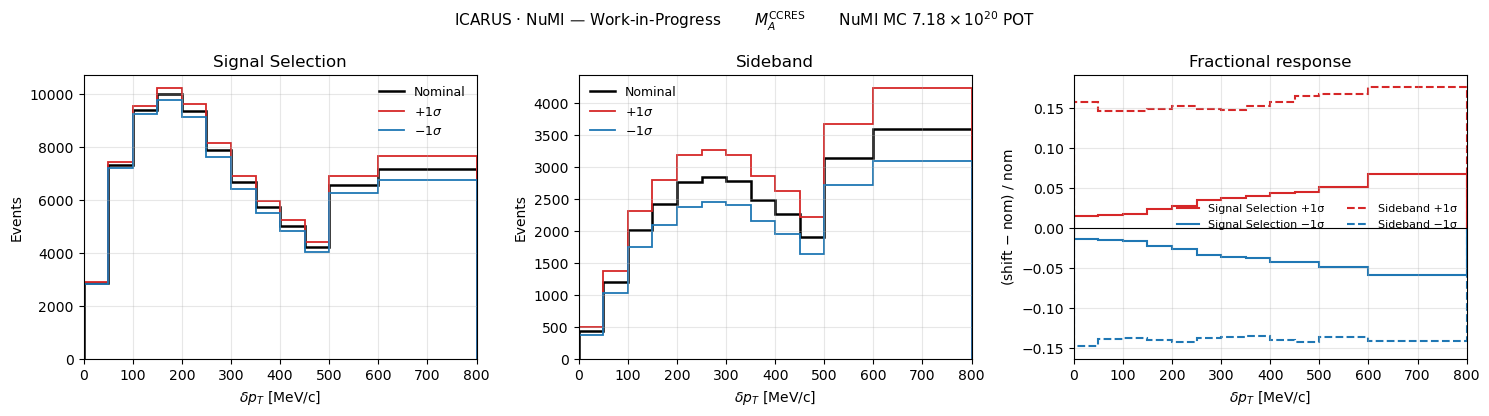

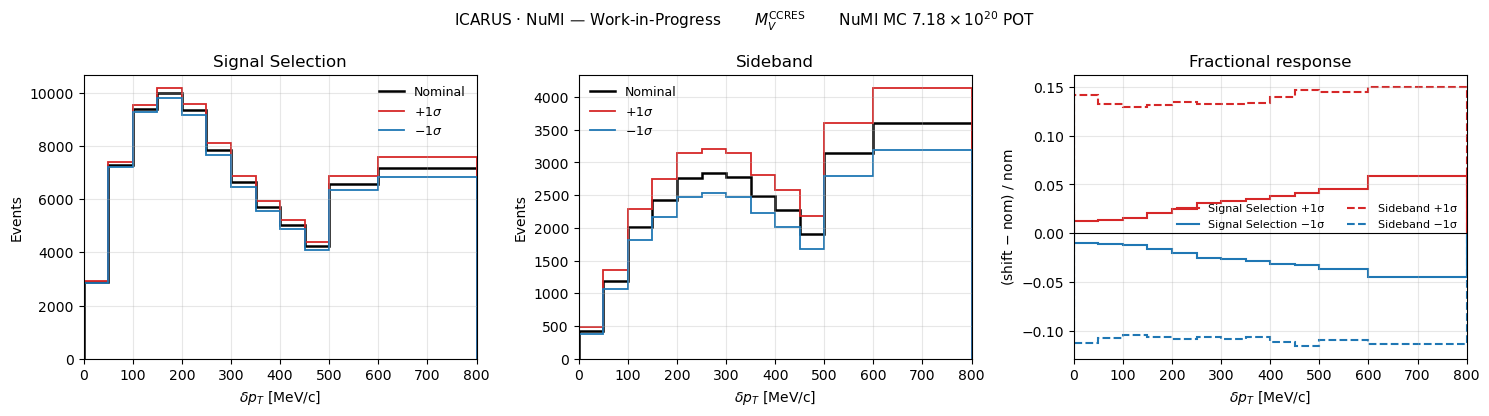

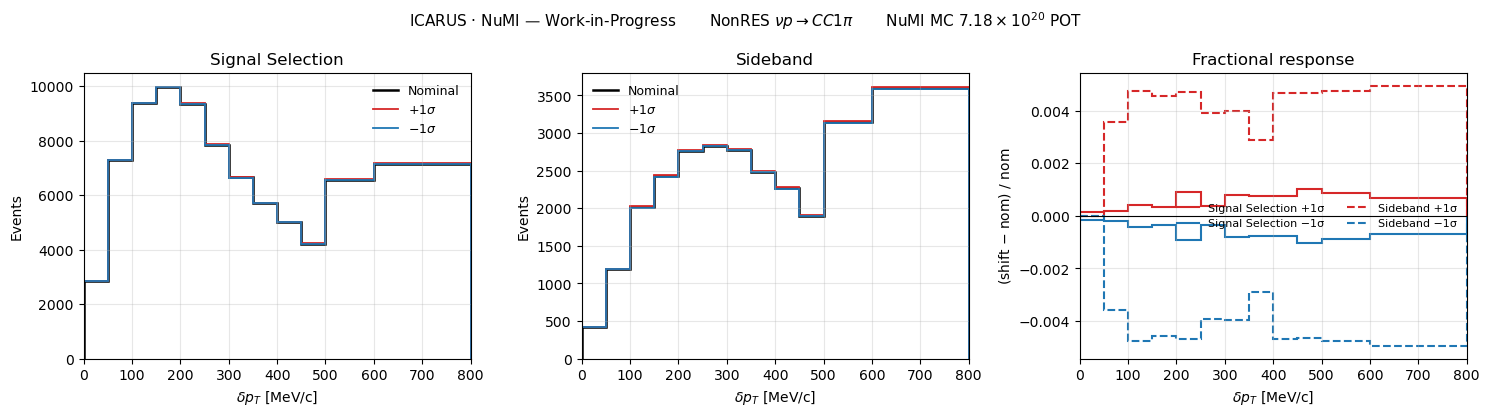

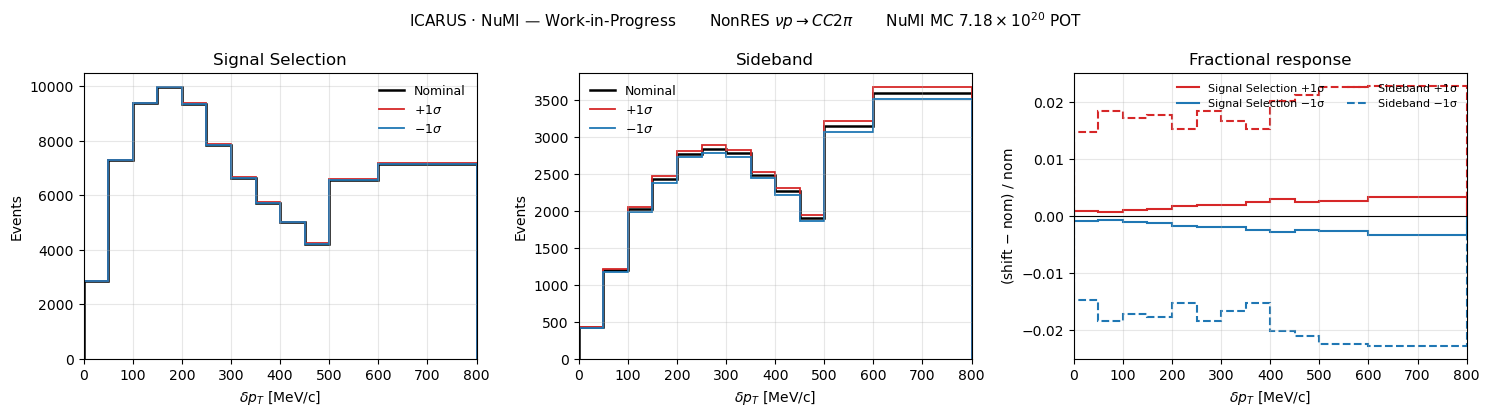

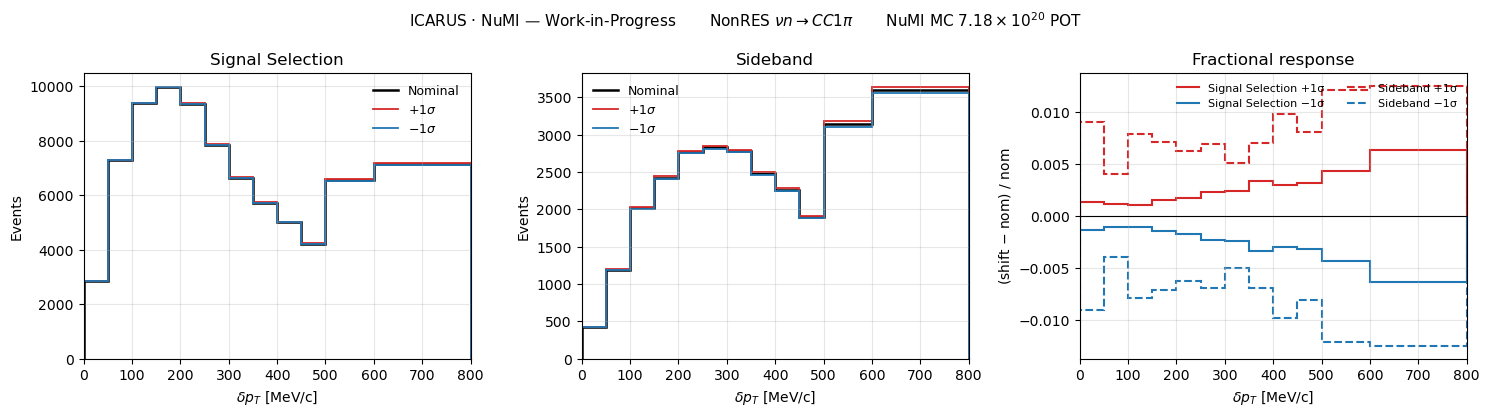

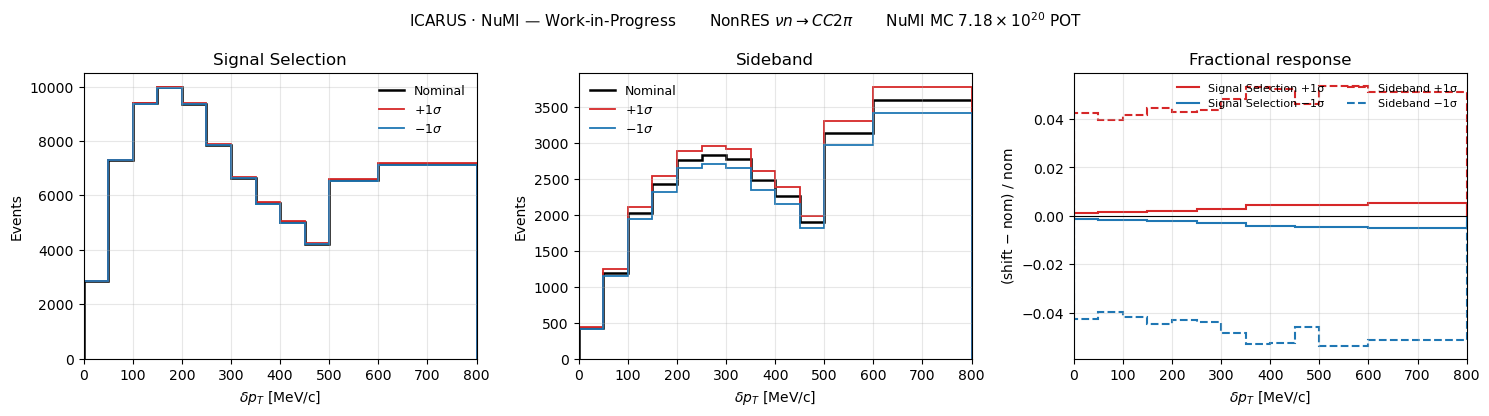

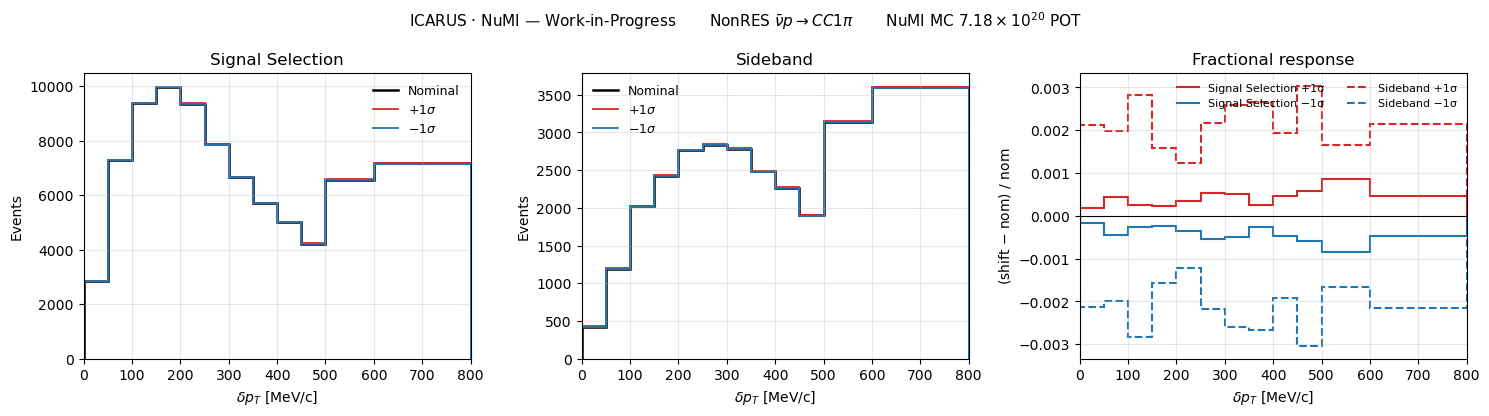

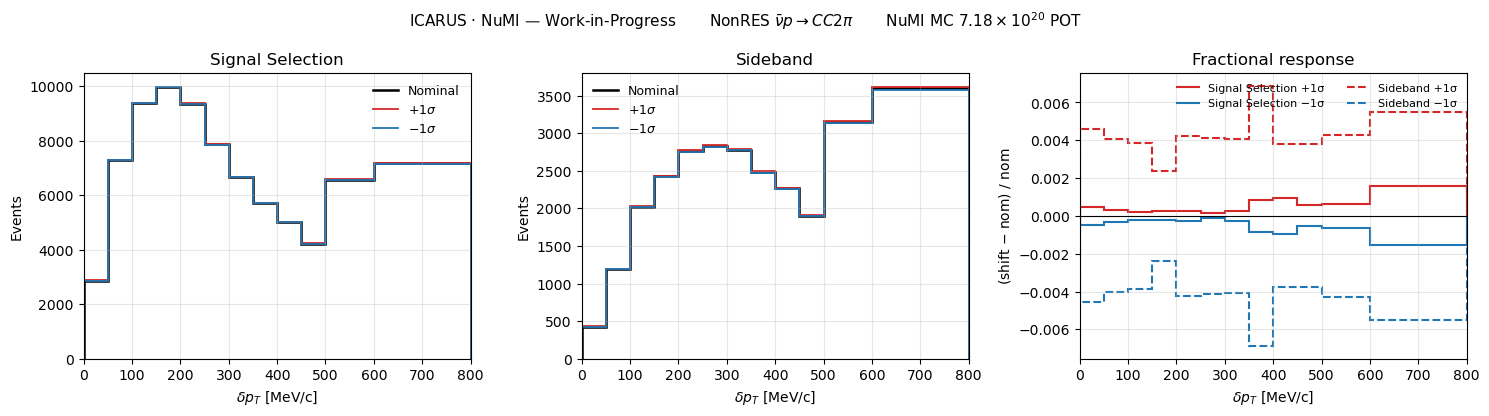

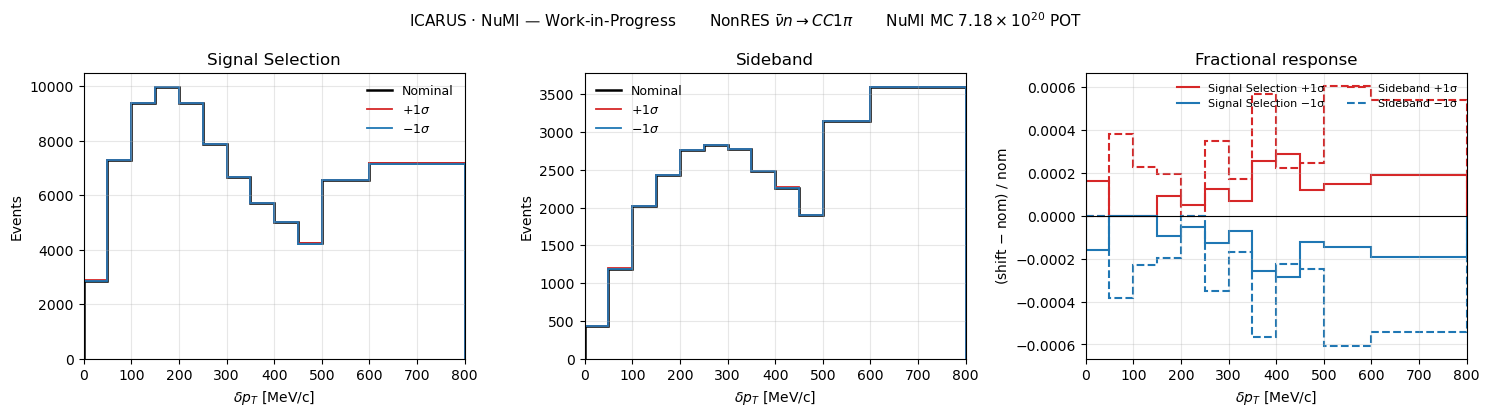

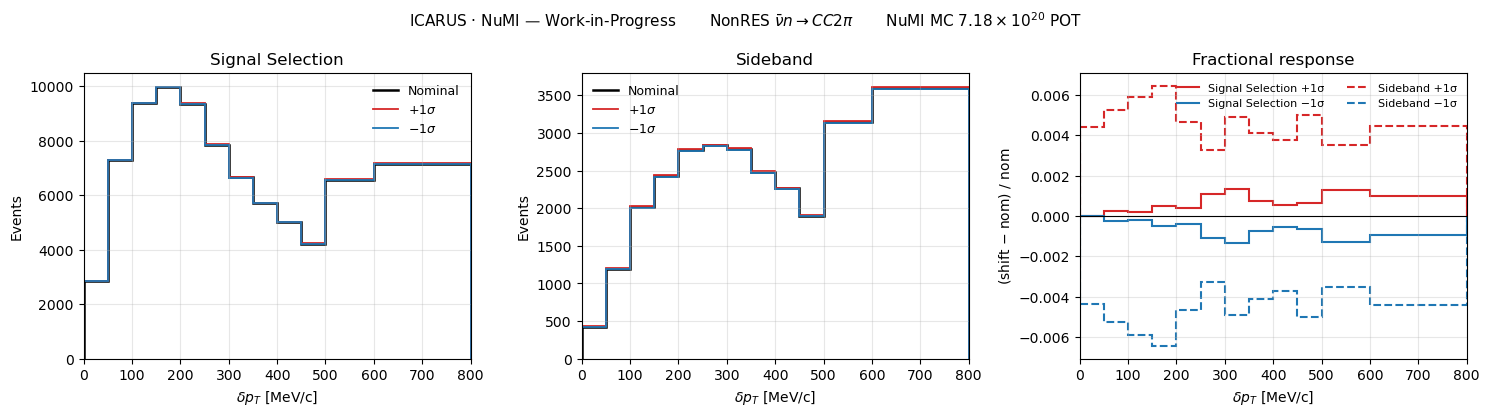

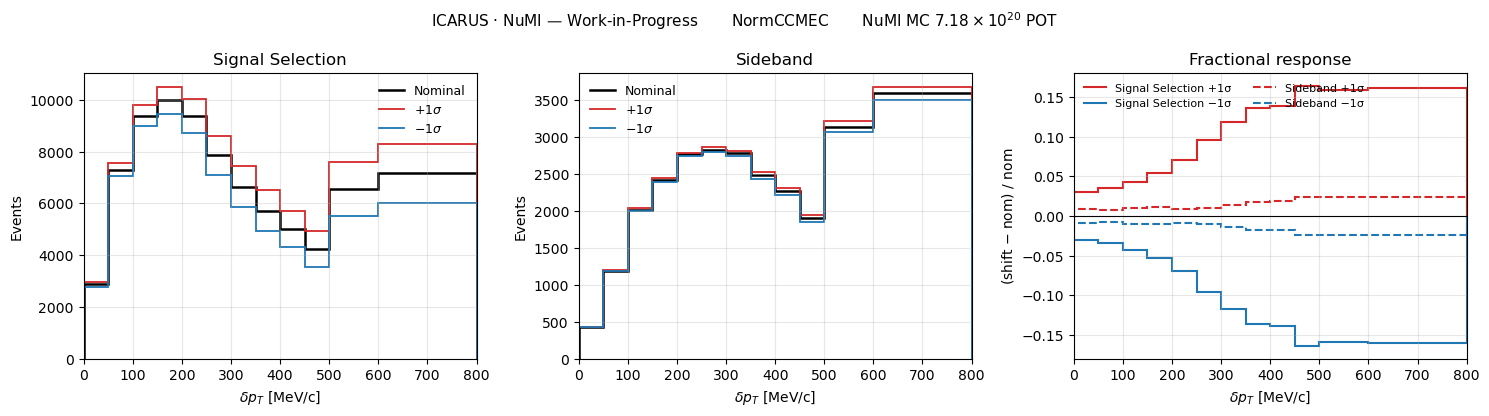

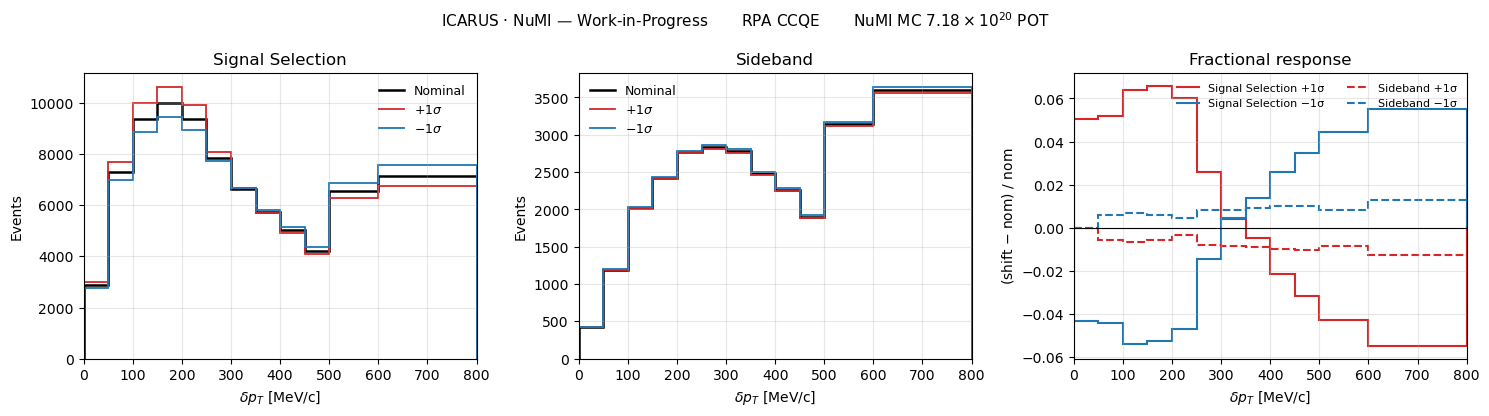

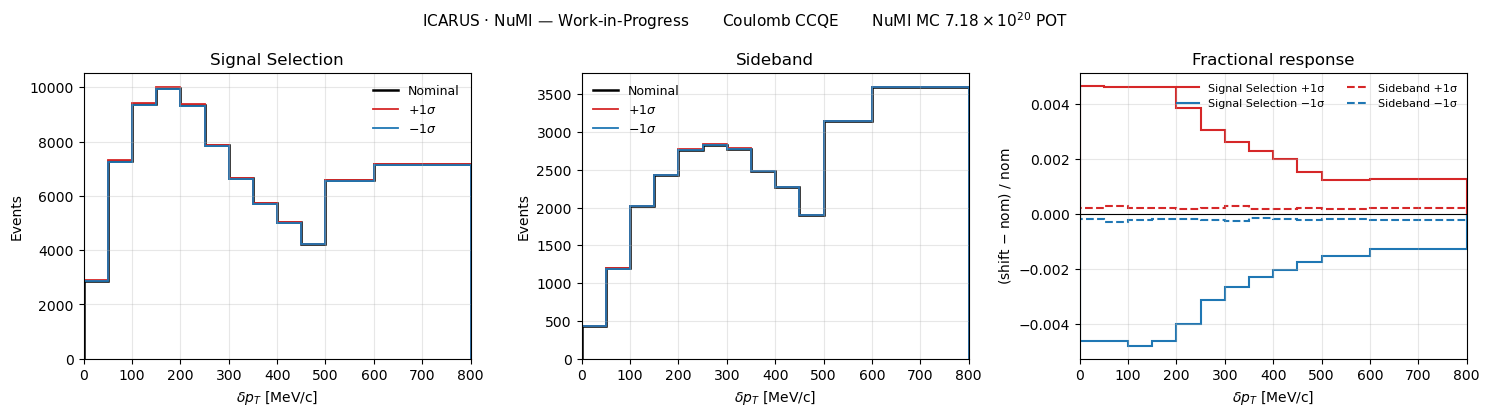

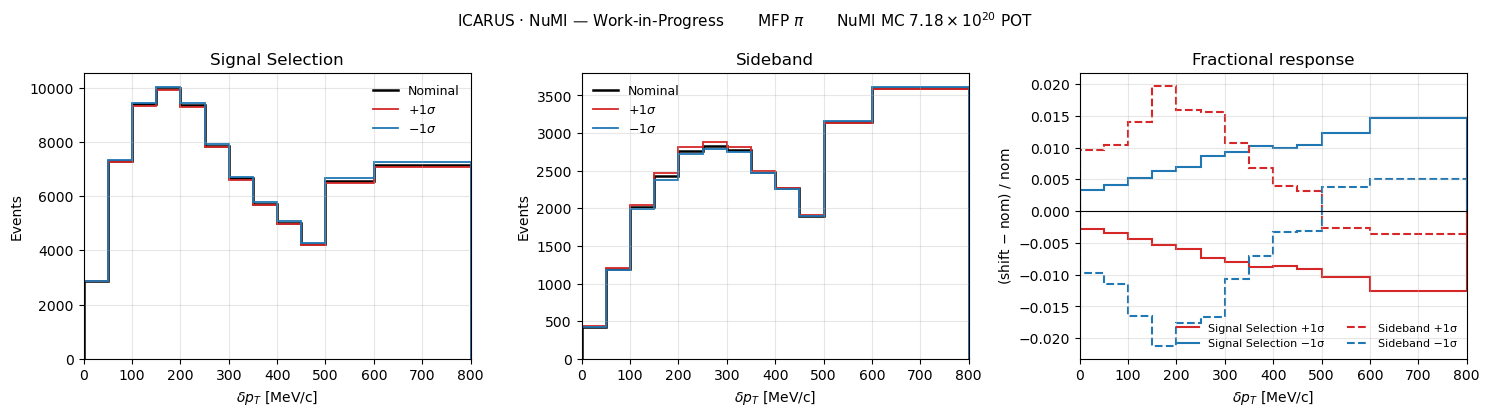

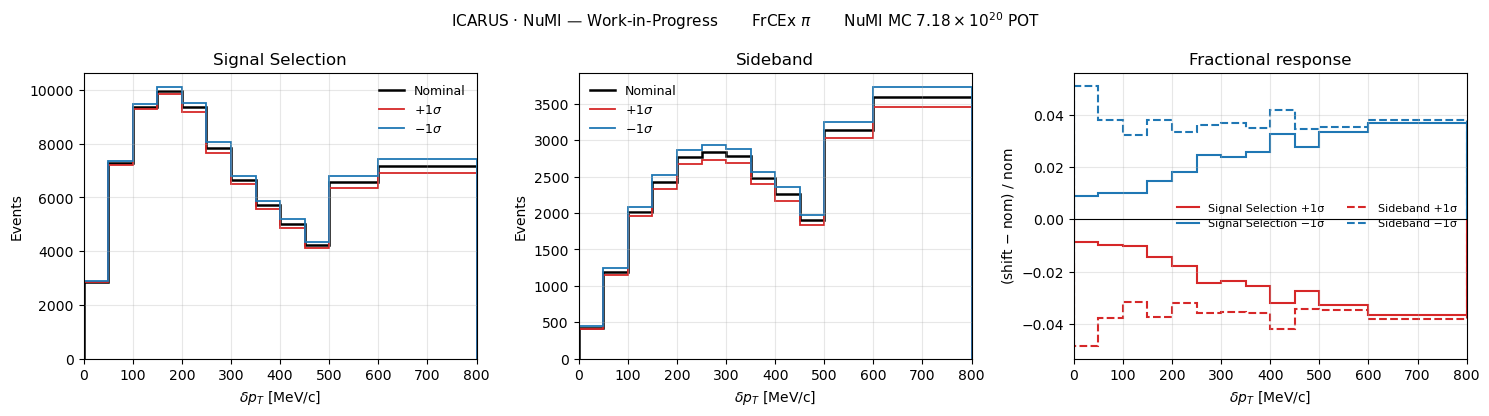

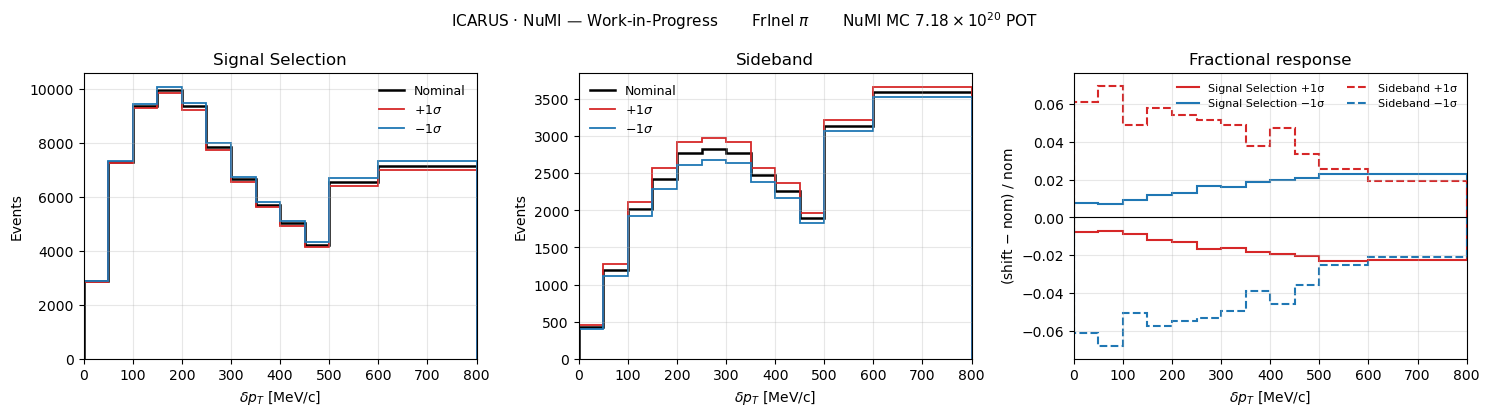

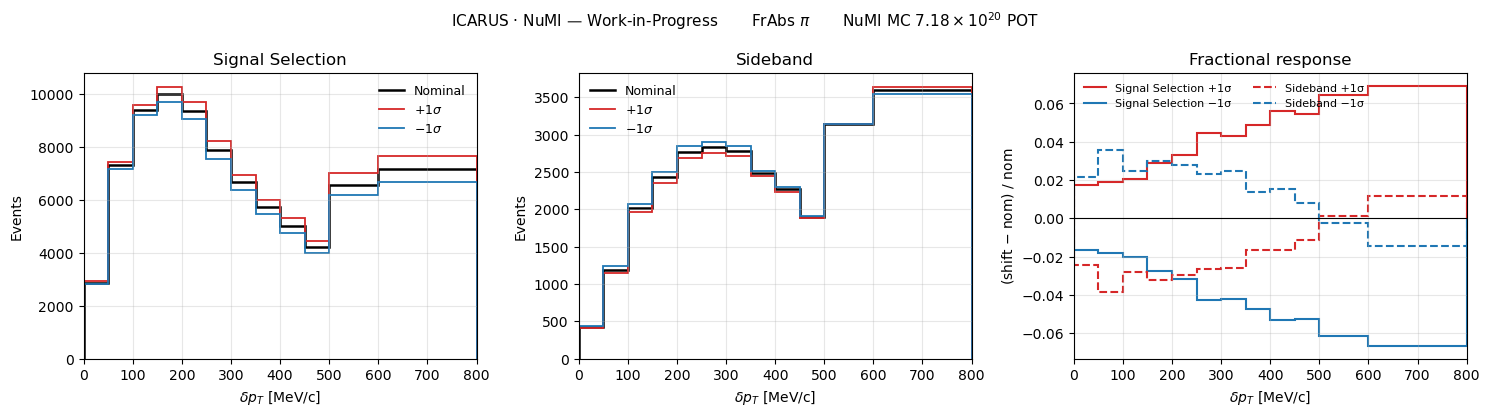

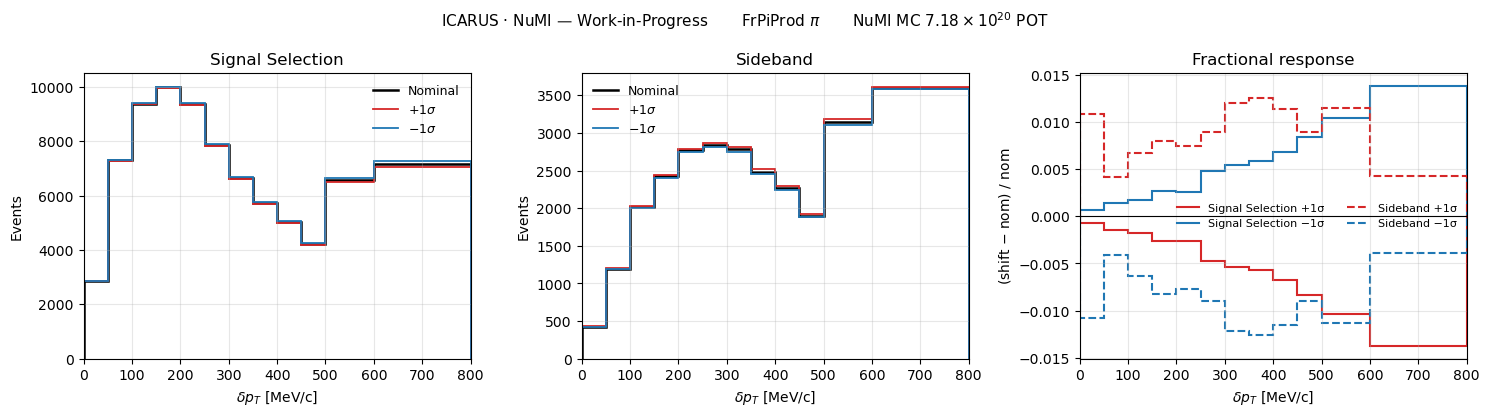

In [4]:
# === Cell 1: imports ===
import uproot
import awkward as ak
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

PREFIX = "GENIEReWeight_SBN_v1_multisigma_"

sample = f["events/full/selected"][f"{PREFIX}MaCCRES"].array(
    library="np", entry_stop=5
)

# === Cell 2: configuration ===
FILE = Path(
    "/Users/rvizarreta/Library/CloudStorage/"
    "GoogleDrive-rvizarreta14@gmail.com/My Drive/"
    "🏛 PhD Repository/🚀 Research/🤖 Experiments&Projects/"
    "ICARUS/ICARUS_CC0pi_Selection/data/"
    "icarus_numi_numu_mc_onbeam_offbeam_syst_gundam.root"
)

POT_LABEL = r"NuMI MC $7.18 \times 10^{20}$ POT"

# δpT binning in MeV/c — adjust to match analysis binning if needed
DPT_BINS = np.array([0, 50, 100, 150, 200, 250, 300, 350,
                     400, 450, 500, 600, 800], dtype=float)
DPT_CENTERS = 0.5 * (DPT_BINS[:-1] + DPT_BINS[1:])

# Dials to scan, in display order. Grouped for plotting.
DIALS = {
    # RES-direct
    "MaCCRES":         r"$M_A^{\rm CCRES}$",
    "MvCCRES":         r"$M_V^{\rm CCRES}$",
    # Non-RES CC backgrounds
    "NonRESBGvpCC1pi":   r"NonRES $\nu p\to CC1\pi$",
    "NonRESBGvpCC2pi":   r"NonRES $\nu p\to CC2\pi$",
    "NonRESBGvnCC1pi":   r"NonRES $\nu n\to CC1\pi$",
    "NonRESBGvnCC2pi":   r"NonRES $\nu n\to CC2\pi$",
    "NonRESBGvbarpCC1pi":r"NonRES $\bar\nu p\to CC1\pi$",
    "NonRESBGvbarpCC2pi":r"NonRES $\bar\nu p\to CC2\pi$",
    "NonRESBGvbarnCC1pi":r"NonRES $\bar\nu n\to CC1\pi$",
    "NonRESBGvbarnCC2pi":r"NonRES $\bar\nu n\to CC2\pi$",
    # MEC / QE cross-checks
    "NormCCMEC":       r"NormCCMEC",
    "RPA_CCQE":        r"RPA CCQE",
    "CoulombCCQE":     r"Coulomb CCQE",
    # FSI (move events between signal and sideband)
    "MFP_pi":          r"MFP $\pi$",
    "FrCEx_pi":        r"FrCEx $\pi$",
    "FrInel_pi":       r"FrInel $\pi$",
    "FrAbs_pi":        r"FrAbs $\pi$",
    "FrPiProd_pi":     r"FrPiProd $\pi$",
}

PREFIX = "GENIEReWeight_SBN_v1_multisigma_"
TREES  = {"Signal Selection": "events/full/selected",
          "Sideband":          "events/full/sideband"}

OUT_DIR = Path("/Users/rvizarreta/Library/CloudStorage/GoogleDrive-rvizarreta14@gmail.com/My Drive/🏛 PhD Repository/🚀 Research/🤖 Experiments&Projects/ICARUS/ICARUS_CC0pi_GUNDAM/gundam-icarus/Notebooks/Plots/dpT/DialResponse")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# === Cell 3 (final): TClonesArray-of-TGraph aware extraction ===
def extract_tgraph_branch(tca_object_array):
    """
    Each entry is a TClonesArray holding one TGraph (the multisigma spline).
    Returns:
        x_common: σ values (taken from event 0, assumed shared across events)
        y_matrix: (N_events, n_points) array of weights
    """
    n_events = len(tca_object_array)
    first_tg = next(iter(tca_object_array[0]))
    x_common = np.asarray(first_tg.member("fX"), dtype=float)
    n_points = len(x_common)
    y_matrix = np.empty((n_events, n_points), dtype=float)
    for i, tca in enumerate(tca_object_array):
        tg = next(iter(tca))
        y_matrix[i] = np.asarray(tg.member("fY"), dtype=float)
    return x_common, y_matrix

# Quick verification on the sample
x_common, y_matrix = extract_tgraph_branch(sample)
print(f"σ points (fX): {x_common}")
print(f"Nominal column index (σ=0): {int(np.where(x_common == 0)[0][0])}")
print(f"First event weights: {y_matrix[0]}")

def idx_for_sigma(x_axis, sigma, tol=1e-6):
    matches = np.where(np.abs(x_axis - sigma) < tol)[0]
    if len(matches) == 0:
        raise RuntimeError(f"σ = {sigma} not present in fX = {x_axis}")
    return int(matches[0])

IDX_PLUS1  = idx_for_sigma(x_common, +1)   # should be 4
IDX_MINUS1 = idx_for_sigma(x_common, -1)   # should be 2
IDX_NOM    = idx_for_sigma(x_common,  0)   # should be 3, fY here must be ~1
print(f"Index map: +1σ→{IDX_PLUS1}, −1σ→{IDX_MINUS1}, nominal→{IDX_NOM}")

# Optional sanity check: nominal column should be 1.0 everywhere
small_check = y_matrix[:, IDX_NOM]
print(f"Nominal column stats: min={small_check.min():.4f}, "
      f"max={small_check.max():.4f}, mean={small_check.mean():.4f}")

# === Cell 4 (final): load data with entry_stop and a shape guard ===
def load_region(tree_path, dial_names):
    t = f[tree_path]
    n = t.num_entries
    out = {}
    for br in ["reco_dpT_lp", "true_dpT_lp",
               "true_interaction_mode", "true_interaction_type",
               "ppfx_cv_weight"]:
        out[br] = t[br].array(library="np", entry_stop=n)
        assert len(out[br]) == n, f"{br}: got {len(out[br])}, expected {n}"
    out["dials"] = {}
    out["dial_x_axes"] = {}
    missing = []
    for d in dial_names:
        full = f"{PREFIX}{d}"
        try:
            raw = t[full].array(library="np", entry_stop=n)
            if len(raw) != n:
                raw = raw[:n]   # defensive trim in case entry_stop is ignored
            x_axis, y_mat = extract_tgraph_branch(raw)
            assert y_mat.shape[0] == n, (
                f"{full}: y_mat has {y_mat.shape[0]} rows, expected {n}"
            )
            out["dials"][d] = y_mat
            out["dial_x_axes"][d] = x_axis
        except (uproot.exceptions.KeyInFileError, KeyError):
            missing.append(d)
    if missing:
        print(f"  [warn] missing in {tree_path}: {missing}")
    return out

data = {}
for label, path in TREES.items():
    print(f"Loading {label} ({path}) ...")
    data[label] = load_region(path, list(DIALS))
    n = len(data[label]['reco_dpT_lp'])
    # cross-check that all dial y_matrices have the right number of rows
    shapes = {d: data[label]['dials'][d].shape for d in data[label]['dials']}
    print(f"  N events = {n}, dials loaded = {len(shapes)}, "
          f"sample y_mat shape = {next(iter(shapes.values()))}")

# === Cell 5: response computation ===
def histogram_with_weight(values, weights, bins=DPT_BINS):
    values = np.asarray(values, dtype=float)
    weights = np.asarray(weights, dtype=float)
    finite = np.isfinite(values) & np.isfinite(weights)
    h, _ = np.histogram(values[finite], bins=bins, weights=weights[finite])
    return h

def compute_dial_response(region_data, dial):
    cv_w   = region_data["ppfx_cv_weight"]
    y_mat  = region_data["dials"][dial]
    x_axis = region_data["dial_x_axes"][dial]
    i_plus  = idx_for_sigma(x_axis, +1)
    i_minus = idx_for_sigma(x_axis, -1)
    w_plus  = cv_w * y_mat[:, i_plus]
    w_minus = cv_w * y_mat[:, i_minus]
    x = region_data["reco_dpT_lp"]
    return (histogram_with_weight(x, cv_w),
            histogram_with_weight(x, w_plus),
            histogram_with_weight(x, w_minus))

responses = {}
for region in TREES:
    responses[region] = {}
    for dial in data[region]["dials"]:
        responses[region][dial] = compute_dial_response(data[region], dial)
    print(f"{region}: computed responses for {len(responses[region])} dials")

# === Cell 6: per-dial plot ===
def plot_dial_response(dial, save=True):
    """Three-panel plot: signal δpT, sideband δpT, fractional change in both."""
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
    label = DIALS[dial]

    for ax, region in zip(axes[:2], TREES):
        h_nom, h_plus, h_minus = responses[region][dial]
        ax.stairs(h_nom,   DPT_BINS, color="k", lw=1.8, label="Nominal")
        ax.stairs(h_plus,  DPT_BINS, color="C3", lw=1.3, label=r"$+1\sigma$")
        ax.stairs(h_minus, DPT_BINS, color="C0", lw=1.3, label=r"$-1\sigma$")
        ax.set_xlabel(r"$\delta p_T$ [MeV/c]")
        ax.set_ylabel("Events")
        ax.set_title(region)
        ax.set_xlim(DPT_BINS[0], DPT_BINS[-1])
        ax.legend(frameon=False, fontsize=9)
        ax.grid(alpha=0.3)

    # Ratio panel: fractional change in both regions
    ax = axes[2]
    for region, ls in zip(TREES, ["-", "--"]):
        h_nom, h_plus, h_minus = responses[region][dial]
        with np.errstate(divide="ignore", invalid="ignore"):
            r_plus  = np.where(h_nom > 0, (h_plus  - h_nom) / h_nom, 0.0)
            r_minus = np.where(h_nom > 0, (h_minus - h_nom) / h_nom, 0.0)
        ax.stairs(r_plus,  DPT_BINS, color="C3", lw=1.5, ls=ls,
                  label=f"{region} +1σ")
        ax.stairs(r_minus, DPT_BINS, color="C0", lw=1.5, ls=ls,
                  label=f"{region} −1σ")
    ax.axhline(0, color="k", lw=0.8)
    ax.set_xlabel(r"$\delta p_T$ [MeV/c]")
    ax.set_ylabel(r"(shift $-$ nom) / nom")
    ax.set_title("Fractional response")
    ax.set_xlim(DPT_BINS[0], DPT_BINS[-1])
    ax.legend(frameon=False, fontsize=8, ncol=2)
    ax.grid(alpha=0.3)

    fig.suptitle(f"ICARUS · NuMI — Work-in-Progress       {label}       {POT_LABEL}",
                 fontsize=11)
    fig.tight_layout()
    if save:
        fig.savefig(OUT_DIR / f"response_{dial}.pdf", bbox_inches="tight")
        save_fig(fig, str(OUT_DIR), f'response_{dial}')
    plt.show()

# === Cell 7: produce all per-dial plots ===
for dial in DIALS:
    plot_dial_response(dial)

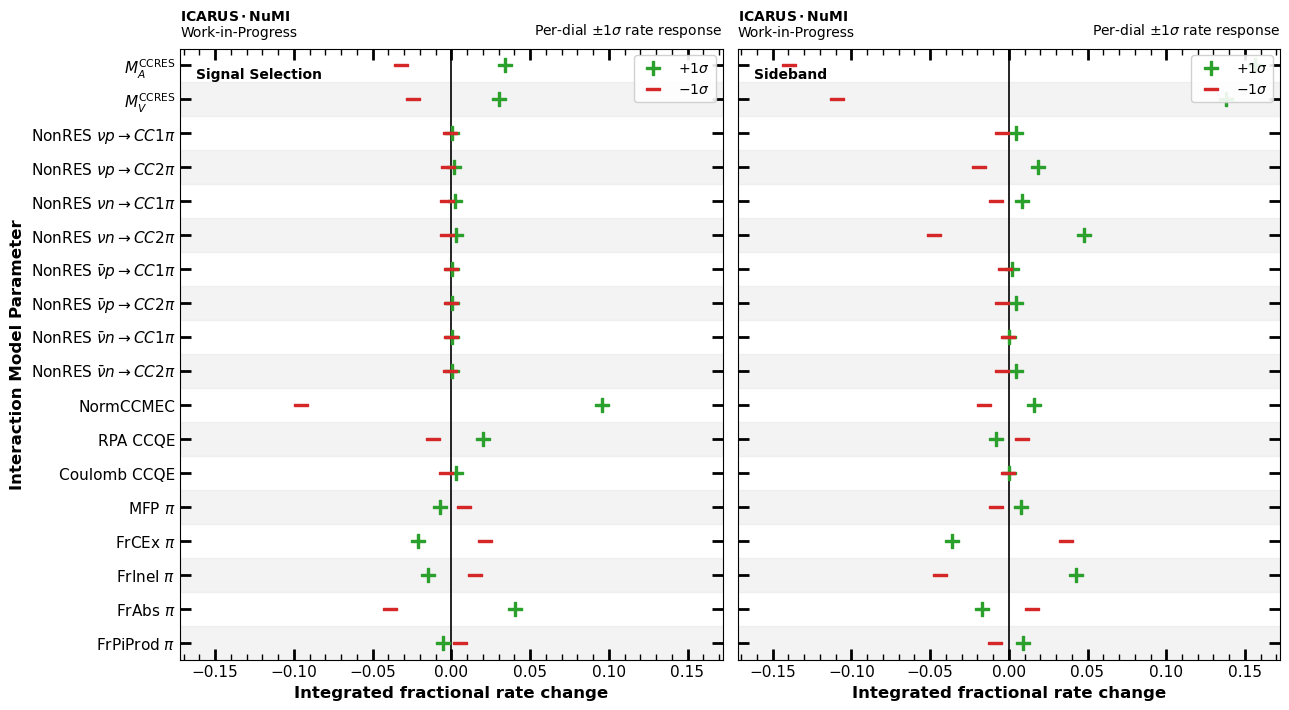

In [5]:
# === Cell 8 (split, final styling): smaller ± markers in green/red ===
fig, (ax_sig, ax_side) = plt.subplots(
    1, 2, figsize=(13, max(5, 0.4 * len(DIALS))), sharey=True
)

dial_names = list(DIALS.keys())
y = np.arange(len(dial_names))

sig_plus,  sig_minus  = [], []
side_plus, side_minus = [], []
for dial in dial_names:
    h0, hp, hm = responses["Signal Selection"][dial]
    n0 = h0.sum()
    sig_plus .append((hp.sum() - n0) / n0 if n0 > 0 else 0.0)
    sig_minus.append((hm.sum() - n0) / n0 if n0 > 0 else 0.0)

    h0, hp, hm = responses["Sideband"][dial]
    n0 = h0.sum()
    side_plus .append((hp.sum() - n0) / n0 if n0 > 0 else 0.0)
    side_minus.append((hm.sum() - n0) / n0 if n0 > 0 else 0.0)

PLUS_COLOR  = "#2ca02c"   # green
MINUS_COLOR = "#d62728"   # red


def style_panel(ax, plus, minus, region_label):
    # Alternating row shading — odd rows shaded, so row 0 has no shadow
    for i in range(len(dial_names)):
        if i % 2 == 1:
            ax.axhspan(i - 0.5, i + 0.5,
                       color="lightgray", alpha=0.25, zorder=0)

    # Smaller, semantic ± markers
    ax.scatter(plus,  y, marker=r"$\mathbf{+}$", s=90, color=PLUS_COLOR,
               label=r"$+1\sigma$", zorder=4)
    ax.scatter(minus, y, marker=r"$\mathbf{-}$", s=90, color=MINUS_COLOR,
               label=r"$-1\sigma$", zorder=4)

    # Zero reference line
    ax.axvline(0, color="black", lw=1.2, zorder=2)

    # Y axis
    ax.set_yticks(y)
    ax.set_yticklabels([DIALS[d] for d in dial_names])
    ax.set_ylim(len(dial_names) - 0.5, -0.5)

    # X axis
    ax.set_xlabel("Integrated fractional rate change",
                  fontsize=12, weight="bold")

    # Ticks (ICARUS style)
    ax.tick_params(axis="both", which="major",
                   labelsize=11, size=8, width=2, direction="in",
                   top=True, right=True, left=True, bottom=True)
    ax.tick_params(axis="x", which="minor",
                   size=4, width=1, direction="in",
                   top=True, bottom=True)
    ax.xaxis.set_minor_locator(plt.matplotlib.ticker.AutoMinorLocator())
    ax.yaxis.set_minor_locator(plt.NullLocator())

    # Region label inside the panel
    ax.text(0.03, 0.97, region_label,
            transform=ax.transAxes, fontsize=10, color="black",
            weight="bold", ha="left", va="top")

    ax.legend(loc="upper right", fontsize=10, framealpha=0.9)


style_panel(ax_sig,  sig_plus,  sig_minus,  "Signal Selection")
style_panel(ax_side, side_plus, side_minus, "Sideband")

ax_sig.set_ylabel("Interaction Model Parameter",
                  fontsize=12, weight="bold")

all_vals = sig_plus + sig_minus + side_plus + side_minus
xmax = 1.1 * max(abs(v) for v in all_vals)
ax_sig.set_xlim(-xmax, xmax)
ax_side.set_xlim(-xmax, xmax)

# ICARUS title block on each panel
for ax in (ax_sig, ax_side):
    ax.text(0.0, 1.015,
            r"$\bf{ICARUS \cdot NuMI}$" + "\n" + "Work-in-Progress",
            transform=ax.transAxes, fontsize=10,
            verticalalignment="bottom", horizontalalignment="left")
    ax.text(1.0, 1.015,
            r"Per-dial $\pm 1\sigma$ rate response",
            transform=ax.transAxes, fontsize=10,
            verticalalignment="bottom", horizontalalignment="right")

fig.tight_layout()
fig.savefig(OUT_DIR / "summary_rate_response_split.pdf", bbox_inches="tight")
save_fig(fig, str(OUT_DIR), 'summary_rate_response_split')
plt.show()

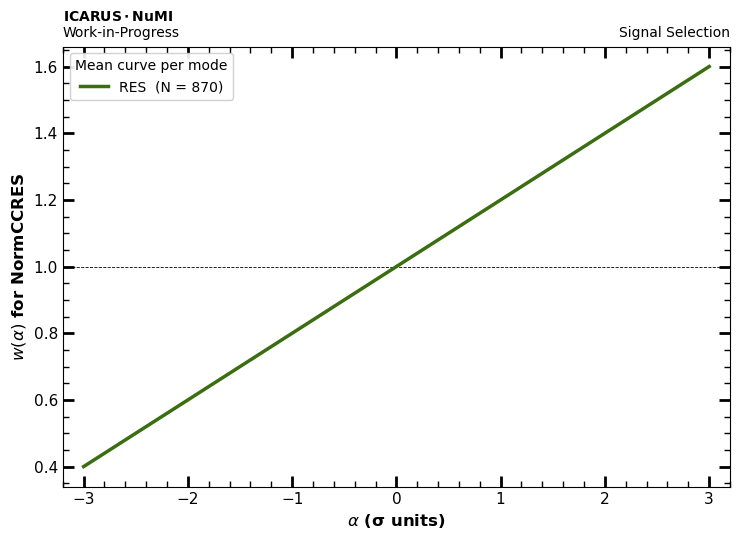

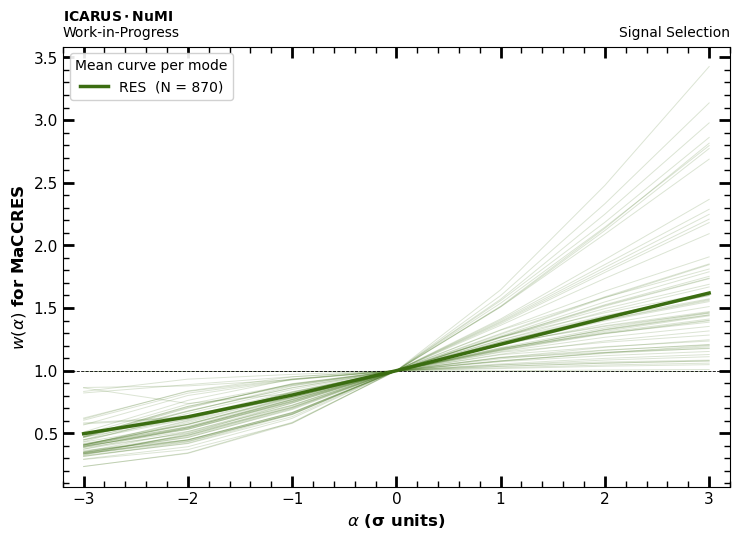

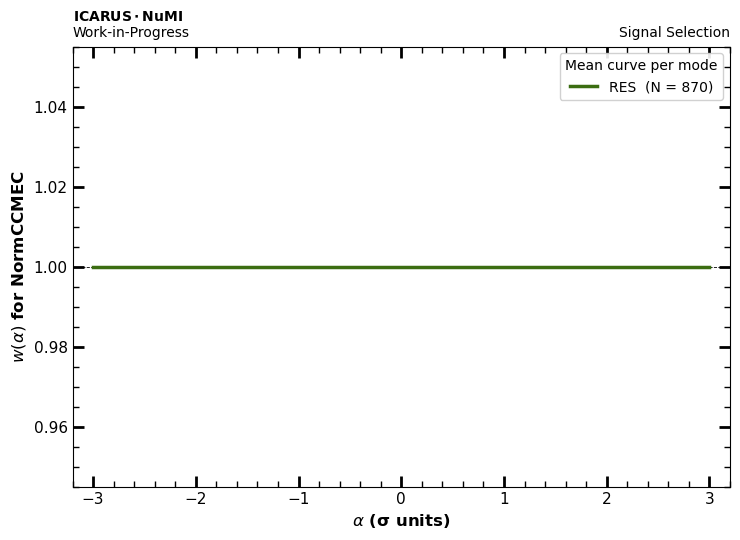

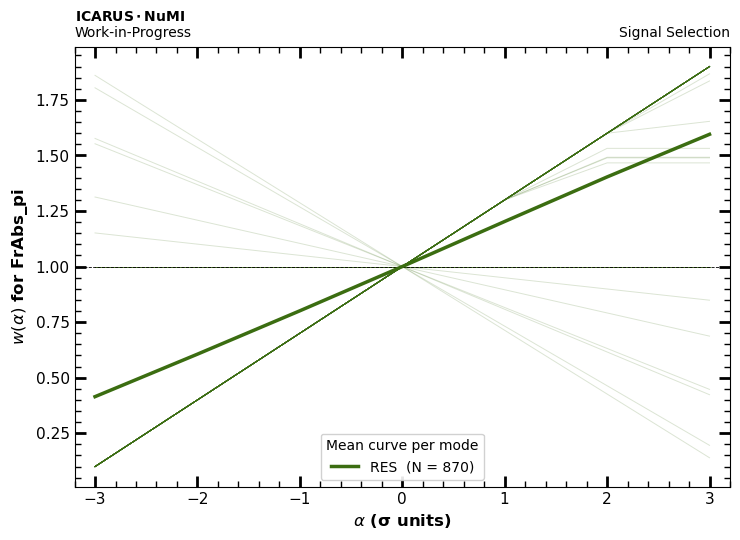

In [18]:
# === Cell: visualize per-event TGraphs for any dial ===
import numpy as np
import matplotlib.pyplot as plt

MODE_INFO = {
    1:  ("#3B6D11", "RES")
}


def plot_dial_tgraphs(dial_name, n_show=400, n_for_mean=5000,
                      region="Signal Selection", seed=42):
    """
    Read the per-event TGraphs of a dial straight out of the ROOT file and
    overlay them, colored by true interaction mode. Heavier lines show the
    per-mode mean weight curve.
    """
    # Branch name: synthetic for NormCCRES, GENIE prefix for everything else
    if dial_name == "NormCCRES":
        branch = "Synthetic_multisigma_NormCCRES"
    else:
        branch = f"GENIEReWeight_SBN_v1_multisigma_{dial_name}"

    tree_path = ("events/full/selected" if region == "Signal Selection"
                 else "events/full/sideband")

    t = uproot.open(FILE)[tree_path]
    n_total = t.num_entries

    # Sample once, use the same indices for both spaghetti and means
    rng = np.random.default_rng(seed)
    idx = rng.choice(n_total, min(n_for_mean, n_total), replace=False)
    idx_sorted = np.sort(idx)   # uproot reads sequentially → sort for speed

    tgraphs = t[branch].array(library="np", entry_stop=n_total)
    modes   = t["true_interaction_mode"].array(library="np", entry_stop=n_total)

    # Extract fX and fY for the sampled events
    fX = None
    fY = np.full((len(idx_sorted), 7), np.nan)
    for j, i in enumerate(idx_sorted):
        tca = tgraphs[i]
        if tca is None or len(tca) == 0:
            continue
        tg = next(iter(tca))
        if fX is None:
            fX = np.asarray(tg.member("fX"))
        fY[j] = np.asarray(tg.member("fY"))
    modes_sub = modes[idx_sorted]

    if fX is None:
        print(f"No TGraphs found for {dial_name}")
        return None, None

    # --- Plot ---
    fig, ax = plt.subplots(figsize=(7.5, 5.5))

    # Spaghetti: light per-event curves
    n_spaghetti = min(n_show, len(fY))
    for j in range(n_spaghetti):
        m = int(modes_sub[j])
        if m not in MODE_INFO:
            continue
        color, _ = MODE_INFO.get(m, ("#888780", f"Mode {m}"))
        ax.plot(fX, fY[j], color=color, alpha=0.18, lw=0.7, zorder=2)

    # Heavier mean curves per mode
    for m in sorted(MODE_INFO.keys()):
        mask = modes_sub == m
        if mask.sum() < 5:
            continue
        mean_y = np.nanmean(fY[mask], axis=0)
        color, label = MODE_INFO[m]
        ax.plot(fX, mean_y, color=color, lw=2.5, zorder=5,
                label=f"{label}  (N = {int(mask.sum())})")

    # Reference line at w = 1
    ax.axhline(1.0, color="black", lw=0.6, ls="--", zorder=3)

    # ICARUS styling
    ax.set_xlabel(r"$\alpha$ (σ units)", fontsize=12, weight="bold")
    ax.set_ylabel(rf"$w(\alpha)$ for {dial_name}", fontsize=12, weight="bold")
    ax.set_xlim(-3.2, 3.2)

    ax.tick_params(axis="both", which="major", labelsize=11,
                   size=8, width=2, direction="in",
                   top=True, right=True, left=True, bottom=True)
    ax.tick_params(axis="both", which="minor", size=4, width=1, direction="in",
                   top=True, right=True, left=True, bottom=True)
    ax.minorticks_on()

    ax.legend(loc="best", fontsize=10, framealpha=0.9,
              title="Mean curve per mode")

    ax.text(0.0, 1.015,
            r"$\bf{ICARUS \cdot NuMI}$" + "\n" + "Work-in-Progress",
            transform=ax.transAxes, fontsize=10,
            verticalalignment="bottom", horizontalalignment="left")
    ax.text(1.0, 1.015, region,
            transform=ax.transAxes, fontsize=10,
            verticalalignment="bottom", horizontalalignment="right")

    fig.tight_layout()
    return fig, ax


# === Example calls ===

# 1. The synthetic dial. RES events should be perfectly linear (1 + 0.2α),
#    everything else should sit at 1 across all σ.
fig, _ = plot_dial_tgraphs("NormCCRES")
save_fig(fig, str(OUT_DIR), 'tgraphs_NormCCRES')
plt.show()

# 2. A real GENIE form-factor dial. RES events have non-trivial,
#    per-event-different curves; non-RES events sit at 1.
fig, _ = plot_dial_tgraphs("MaCCRES")
save_fig(fig, str(OUT_DIR), 'tgraphs_MaCCRES')
plt.show()

# 3. A rate dial for a different interaction mode. Only MEC events move;
#    asymmetric because GENIE's normalization variation has different
#    impact at +1σ vs −1σ.
fig, _ = plot_dial_tgraphs("NormCCMEC")
save_fig(fig, str(OUT_DIR), 'tgraphs_NormCCMEC')
plt.show()

# 4. A pion FSI dial. Touches anything with pions in the final state —
#    even non-RES events end up affected because their final-state pions
#    can rescatter.
fig, _ = plot_dial_tgraphs("FrAbs_pi")
save_fig(fig, str(OUT_DIR), 'tgraphs_FrAbs_pi')
plt.show()

In [20]:
import uproot
import numpy as np

# Load both trees
f = uproot.open(FILE)
t_sig  = f["events/full/selected"]
t_side = f["events/full/sideband"]

# Read enough to identify and compare events. Vertex coordinates are the
# most reliable unique key here (run/subrun/event aren't in your branch list).
sig_vx   = t_sig["true_vertex_x"].array(library="np")
sig_vy   = t_sig["true_vertex_y"].array(library="np")
sig_vz   = t_sig["true_vertex_z"].array(library="np")
sig_mode = t_sig["true_interaction_mode"].array(library="np")

side_vx   = t_side["true_vertex_x"].array(library="np")
side_vy   = t_side["true_vertex_y"].array(library="np")
side_vz   = t_side["true_vertex_z"].array(library="np")
side_mode = t_side["true_interaction_mode"].array(library="np")

# Read the NormCCMEC w(+1σ) for both trees
def read_w_plus(tree):
    n = tree.num_entries
    w = np.ones(n)
    tgs = tree["GENIEReWeight_SBN_v1_multisigma_NormCCMEC"].array(
        library="np", entry_stop=n)
    for i, tca in enumerate(tgs):
        if tca is None or len(tca) == 0:
            continue
        tg = next(iter(tca))
        fX = np.asarray(tg.member("fX"))
        fY = np.asarray(tg.member("fY"))
        w[i] = fY[np.where(fX == 1)[0][0]]
    return w

w_sig  = read_w_plus(t_sig)
w_side = read_w_plus(t_side)

# Pick the anomalous sideband events: w ≠ 1 AND not MEC mode
anomalous = (np.abs(w_side - 1) > 1e-6) & (side_mode != 10)
print(f"Anomalous sideband events (w ≠ 1, mode ≠ MEC): {anomalous.sum()}")

# For the first handful of these, find the matching event in the signal tree
# by vertex coordinates and compare both the mode and the NormCCMEC weight.
N_CHECK = 10
side_idx_to_check = np.where(anomalous)[0][:N_CHECK]

print(f"\nChecking {N_CHECK} anomalous sideband events:")
print(f"{'idx':>6} {'side_mode':>10} {'side_w':>8}  |  "
      f"{'sig_idx':>7} {'sig_mode':>9} {'sig_w':>8}   match")
print("-" * 80)

# Vertex match tolerance
TOL = 1e-4

n_matched = 0
n_consistent = 0
for si in side_idx_to_check:
    vx, vy, vz = side_vx[si], side_vy[si], side_vz[si]
    # Find matching event in signal tree by vertex
    dist = np.sqrt((sig_vx - vx)**2 + (sig_vy - vy)**2 + (sig_vz - vz)**2)
    match_idx = np.argmin(dist)
    if dist[match_idx] > TOL:
        print(f"{si:>6d} {int(side_mode[si]):>10d} {w_side[si]:>8.4f}  |  "
              f"  (no match in signal tree within {TOL})")
        continue
    n_matched += 1
    sig_w_here = w_sig[match_idx]
    sig_mode_here = int(sig_mode[match_idx])
    consistent = "✓" if (
        sig_mode_here == int(side_mode[si]) and
        abs(sig_w_here - w_side[si]) < 1e-6
    ) else "✗"
    if consistent == "✓":
        n_consistent += 1
    print(f"{si:>6d} {int(side_mode[si]):>10d} {w_side[si]:>8.4f}  |  "
          f"{match_idx:>7d} {sig_mode_here:>9d} {sig_w_here:>8.4f}   {consistent}")

print(f"\nMatched: {n_matched}/{N_CHECK}, consistent: {n_consistent}/{n_matched}")

Anomalous sideband events (w ≠ 1, mode ≠ MEC): 6474

Checking 10 anomalous sideband events:
   idx  side_mode   side_w  |  sig_idx  sig_mode    sig_w   match
--------------------------------------------------------------------------------
     2          1   1.5000  |    (no match in signal tree within 0.0001)
     4          1   1.5000  |    (no match in signal tree within 0.0001)
    11          0   1.5000  |    (no match in signal tree within 0.0001)
    16          1   1.5000  |    (no match in signal tree within 0.0001)
    24          1   1.5000  |    (no match in signal tree within 0.0001)
    31          2   1.5000  |    (no match in signal tree within 0.0001)
    41          1   1.5000  |    (no match in signal tree within 0.0001)
    42          1   1.5000  |    (no match in signal tree within 0.0001)
    48          0   1.5000  |    (no match in signal tree within 0.0001)
    50          2   1.5000  |    (no match in signal tree within 0.0001)

Matched: 0/10, consistent: 0/0

In [10]:
import uproot
import numpy as np

t = uproot.open(FILE)["events/full/sideband"]
modes = t["true_interaction_mode"].array(library="np")
w_cv  = t["ppfx_cv_weight"].array(library="np")

# Pull NormCCMEC weight at α=+1 and α=-1 for every sideband event
tgs = t["GENIEReWeight_SBN_v1_multisigma_NormCCMEC"].array(
    library="np", entry_stop=t.num_entries
)
w_plus  = np.ones(len(modes))
w_minus = np.ones(len(modes))
for i, tca in enumerate(tgs):
    if tca is None or len(tca) == 0:
        continue
    tg = next(iter(tca))
    fX = np.asarray(tg.member("fX"))
    fY = np.asarray(tg.member("fY"))
    ip = np.where(fX == 1)[0][0]
    im = np.where(fX == -1)[0][0]
    w_plus[i]  = fY[ip]
    w_minus[i] = fY[im]

n_nom   = w_cv.sum()
n_plus  = (w_cv * w_plus).sum()
n_minus = (w_cv * w_minus).sum()

print(f"Sideband nominal:    {n_nom:>10.1f}")
print(f"Sideband at +1σ:     {n_plus:>10.1f}   ({100*(n_plus-n_nom)/n_nom:+6.2f}%)")
print(f"Sideband at −1σ:     {n_minus:>10.1f}   ({100*(n_minus-n_nom)/n_nom:+6.2f}%)")

# Sanity check: which events actually move?
moved = np.abs(w_plus - 1) > 1e-6
print(f"\nEvents with w(+1σ) ≠ 1: {moved.sum()} / {len(moved)}")
print("Modes of moving events:")
for m, label in [(0, "QE"), (1, "RES"), (2, "DIS"), (3, "COH"), (10, "MEC")]:
    n = ((modes == m) & moved).sum()
    if n > 0:
        print(f"  {label:>4}: {n}")

Sideband nominal:       33039.4
Sideband at +1σ:        36250.3   ( +9.72%)
Sideband at −1σ:        29828.5   ( -9.72%)

Events with w(+1σ) ≠ 1: 6690 / 34420
Modes of moving events:
    QE: 306
   RES: 4258
   DIS: 1893
   COH: 17
   MEC: 216


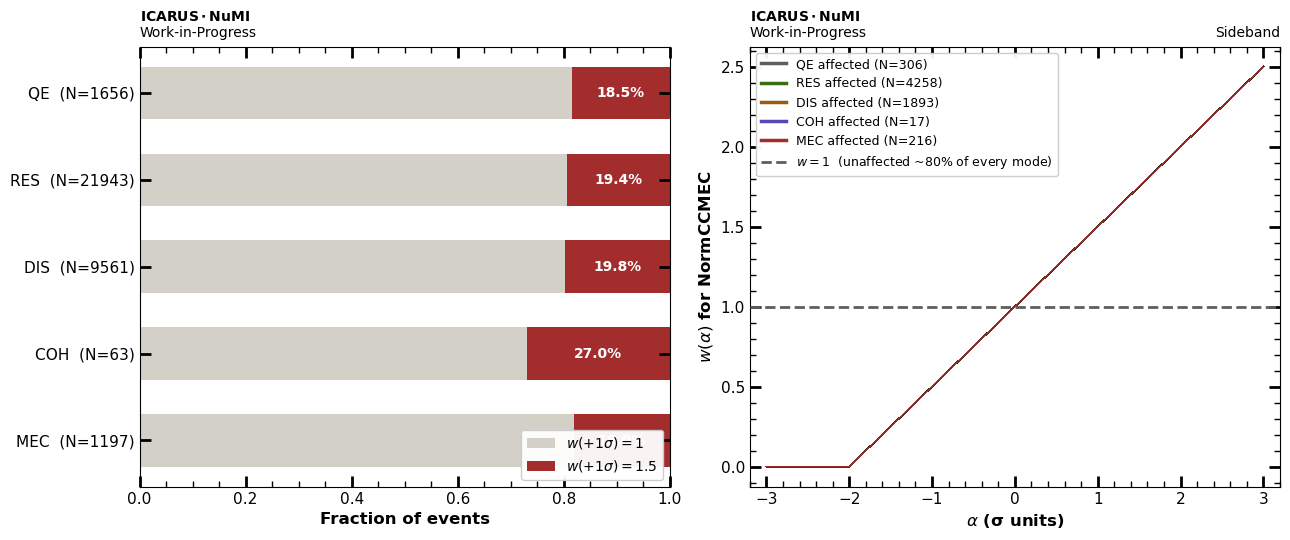

In [12]:
import uproot
import numpy as np
import matplotlib.pyplot as plt

t = uproot.open(FILE)["events/full/sideband"]
modes = t["true_interaction_mode"].array(library="np")
tgs   = t["GENIEReWeight_SBN_v1_multisigma_NormCCMEC"].array(
    library="np", entry_stop=t.num_entries)

# Read full 7-point curves
fX = None
fY_all = np.full((len(modes), 7), 1.0)
for i, tca in enumerate(tgs):
    if tca is None or len(tca) == 0:
        continue
    tg = next(iter(tca))
    if fX is None:
        fX = np.asarray(tg.member("fX"))
    fY_all[i] = np.asarray(tg.member("fY"))

w_plus = fY_all[:, np.where(fX == 1)[0][0]]
moved = np.abs(w_plus - 1) > 1e-6

MODE_INFO = {
    0:  ("QE",  "#5F5E5A"),
    1:  ("RES", "#3B6D11"),
    2:  ("DIS", "#985C0E"),
    3:  ("COH", "#534AB7"),
    10: ("MEC", "#A32D2D"),
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.5))

# Panel 1: stacked bars of moved vs unmoved fraction per mode
labels, n_tot, frac_moved = [], [], []
for m in [0, 1, 2, 3, 10]:
    mask = modes == m
    if mask.sum() == 0: continue
    labels.append(MODE_INFO[m][0])
    n_tot.append(int(mask.sum()))
    frac_moved.append(moved[mask].mean())

y = np.arange(len(labels))
frac_unmoved = [1 - f for f in frac_moved]
ax1.barh(y, frac_unmoved, color="#D3D1C7", label="$w(+1\sigma) = 1$", height=0.6)
ax1.barh(y, frac_moved, left=frac_unmoved, color="#A32D2D",
         label="$w(+1\sigma) = 1.5$", height=0.6)
for i, (f, n) in enumerate(zip(frac_moved, n_tot)):
    ax1.text(1 - f/2, i, f"{100*f:.1f}%", ha="center", va="center",
             color="white", weight="bold", fontsize=10)

ax1.set_yticks(y)
ax1.set_yticklabels([f"{l}  (N={n})" for l, n in zip(labels, n_tot)])
ax1.invert_yaxis()
ax1.set_xlim(0, 1)
ax1.set_xlabel("Fraction of events", fontsize=12, weight="bold")
ax1.tick_params(axis="both", which="major", labelsize=11,
                size=8, width=2, direction="in",
                top=True, right=True, left=True, bottom=True)
ax1.tick_params(axis="x", which="minor", size=4, width=1, direction="in",
                top=True, bottom=True)
ax1.xaxis.set_minor_locator(plt.matplotlib.ticker.AutoMinorLocator())
ax1.legend(loc="lower right", fontsize=10, framealpha=0.95)

# Panel 2: curves of moved events only, colored by mode
rng = np.random.default_rng(42)
for m in [0, 1, 2, 3, 10]:
    mask = moved & (modes == m)
    if mask.sum() == 0: continue
    sample = rng.choice(np.where(mask)[0], min(150, mask.sum()), replace=False)
    label, color = MODE_INFO[m]
    for j in sample:
        ax2.plot(fX, fY_all[j], color=color, alpha=0.15, lw=0.7, zorder=2)
    ax2.plot([], [], color=color, lw=2.5,
             label=f"{label} affected (N={int(mask.sum())})")

# Unaffected reference line
ax2.axhline(1.0, color="#5F5E5A", lw=2, ls="--", zorder=3,
            label=f"$w = 1$  (unaffected ~80% of every mode)")

ax2.set_xlim(-3.2, 3.2)
ax2.set_xlabel(r"$\alpha$ (σ units)", fontsize=12, weight="bold")
ax2.set_ylabel(r"$w(\alpha)$ for NormCCMEC", fontsize=12, weight="bold")
ax2.tick_params(axis="both", which="major", labelsize=11,
                size=8, width=2, direction="in",
                top=True, right=True, left=True, bottom=True)
ax2.tick_params(axis="both", which="minor", size=4, width=1, direction="in",
                top=True, right=True, left=True, bottom=True)
ax2.minorticks_on()
ax2.legend(loc="upper left", fontsize=9, framealpha=0.95)

# ICARUS title block
for ax in (ax1, ax2):
    ax.text(0.0, 1.015,
            r"$\bf{ICARUS \cdot NuMI}$" + "\n" + "Work-in-Progress",
            transform=ax.transAxes, fontsize=10,
            verticalalignment="bottom", horizontalalignment="left")
ax2.text(1.0, 1.015, "Sideband",
         transform=ax2.transAxes, fontsize=10,
         verticalalignment="bottom", horizontalalignment="right")

fig.tight_layout()
fig.savefig("normccmec_bimodal.pdf", bbox_inches="tight")
save_fig(fig, r'.', 'normccmec_bimodal')
plt.show()

Signal Selection: nominal=85806, fake data=82744, Δrate=-3.57%
Sideband: nominal=29301, fake data=25528, Δrate=-12.87%

χ² with no dials (α=0): 694.9  (this is what templates would have to absorb on their own)

Prior width       α_MaCCRES   α_MvCCRES   χ²(fit only)    penalty
-----------------------------------------------------------------
×1 (original)         -1.20       -1.21          211.2       2.91
×2                    -1.17       -1.29          211.2       0.76
×3                    -1.17       -1.31          211.2       0.34
×5                    -1.16       -1.32          211.2       0.12
unconstrained         -1.16       -1.32          211.1       0.00


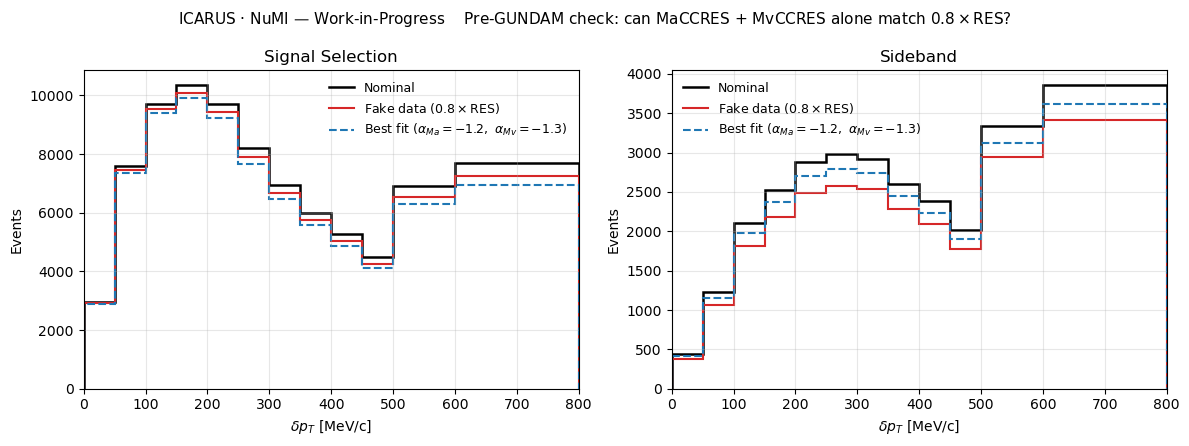

In [11]:
# === Pre-GUNDAM: can MaCCRES + MvCCRES absorb a 20% RES suppression? ===
from scipy.optimize import minimize

# --- Helper: evaluate each event's TGraph at an arbitrary σ value ---
def tgraph_weight_at_sigma(y_matrix, x_axis, alpha):
    """
    Linearly interpolate per-event TGraph weights at σ = alpha.
    y_matrix: (N_events, n_points), x_axis: (n_points,)
    Returns: (N_events,) array of weights.
    """
    a = float(np.clip(alpha, x_axis[0], x_axis[-1]))
    i_hi = int(np.searchsorted(x_axis, a, side="right"))
    i_hi = min(max(i_hi, 1), len(x_axis) - 1)
    i_lo = i_hi - 1
    t = (a - x_axis[i_lo]) / (x_axis[i_hi] - x_axis[i_lo])
    return (1 - t) * y_matrix[:, i_lo] + t * y_matrix[:, i_hi]

# --- Build the RES ×0.8 fake data target ---
RES_MODE = 1   # NUISANCE convention in this file
SUPPRESS = 0.8

def build_fakedata_hist(rd):
    cv_w = rd["ppfx_cv_weight"]
    mode = rd["true_interaction_mode"]
    w    = np.where(mode == RES_MODE, SUPPRESS * cv_w, cv_w)
    return histogram_with_weight(rd["reco_dpT_lp"], w)

fakedata = {region: build_fakedata_hist(data[region]) for region in TREES}
nominal  = {region: histogram_with_weight(data[region]["reco_dpT_lp"],
                                          data[region]["ppfx_cv_weight"])
            for region in TREES}

# Sanity: integrated rate change matches the design of the injection
for region in TREES:
    rate_change = (fakedata[region].sum() - nominal[region].sum()) / nominal[region].sum()
    print(f"{region}: nominal={nominal[region].sum():.0f}, "
          f"fake data={fakedata[region].sum():.0f}, "
          f"Δrate={100*rate_change:+.2f}%")

# --- Build a prediction for arbitrary (α_MaCCRES, α_MvCCRES) ---
def build_prediction_hist(rd, alpha_ma, alpha_mv):
    cv_w   = rd["ppfx_cv_weight"]
    x_axis = rd["dial_x_axes"]["MaCCRES"]   # same axis as MvCCRES
    w_ma   = tgraph_weight_at_sigma(rd["dials"]["MaCCRES"], x_axis, alpha_ma)
    w_mv   = tgraph_weight_at_sigma(rd["dials"]["MvCCRES"], x_axis, alpha_mv)
    total  = cv_w * w_ma * w_mv
    return histogram_with_weight(rd["reco_dpT_lp"], total)

def chi2_data_only(params):
    """Pearson χ² between (α_Ma, α_Mv) prediction and the RES ×0.8 target."""
    alpha_ma, alpha_mv = params
    total = 0.0
    for region in TREES:
        pred = build_prediction_hist(data[region], alpha_ma, alpha_mv)
        fd   = fakedata[region]
        m    = fd > 0
        total += np.sum((pred[m] - fd[m])**2 / fd[m])
    return total

def chi2_with_penalty(params, prior_width):
    """χ² + Gaussian prior penalty at the given prior width (in original σ units)."""
    return chi2_data_only(params) + (params[0]/prior_width)**2 + (params[1]/prior_width)**2

# --- Scan: how does the best fit move as we widen the priors? ---
print(f"\nχ² with no dials (α=0): {chi2_data_only([0.0, 0.0]):.1f}  "
      f"(this is what templates would have to absorb on their own)")
print()
print(f"{'Prior width':<15} {'α_MaCCRES':>11} {'α_MvCCRES':>11} "
      f"{'χ²(fit only)':>14} {'penalty':>10}")
print("-" * 65)

scan = []
for w_label, w_val in [("×1 (original)", 1.0), ("×2", 2.0), ("×3", 3.0),
                       ("×5", 5.0),  ("unconstrained", 1e6)]:
    res = minimize(chi2_with_penalty, x0=[-1.0, -1.0],
                   args=(w_val,), method="Nelder-Mead",
                   options={"xatol": 1e-3, "fatol": 1e-2})
    a_ma, a_mv = res.x
    fit_chi2   = chi2_data_only(res.x)
    penalty    = (a_ma/w_val)**2 + (a_mv/w_val)**2
    print(f"{w_label:<15} {a_ma:>+11.2f} {a_mv:>+11.2f} "
          f"{fit_chi2:>14.1f} {penalty:>10.2f}")
    scan.append((w_label, w_val, a_ma, a_mv, fit_chi2))

# --- Visualize: nominal, fake data, and best-fit at the unconstrained limit ---
a_ma_uc, a_mv_uc = scan[-1][2], scan[-1][3]
best_pred = {region: build_prediction_hist(data[region], a_ma_uc, a_mv_uc)
             for region in TREES}

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, region in zip(axes, TREES):
    ax.stairs(nominal[region],  DPT_BINS, color="k",  lw=1.8, label="Nominal")
    ax.stairs(fakedata[region], DPT_BINS, color="C3", lw=1.5, label=r"Fake data ($0.8\times$RES)")
    ax.stairs(best_pred[region],DPT_BINS, color="C0", lw=1.5, ls="--",
              label=fr"Best fit ($\alpha_{{Ma}}={a_ma_uc:+.1f},\ \alpha_{{Mv}}={a_mv_uc:+.1f}$)")
    ax.set_xlabel(r"$\delta p_T$ [MeV/c]"); ax.set_ylabel("Events")
    ax.set_title(region); ax.legend(frameon=False, fontsize=9)
    ax.set_xlim(DPT_BINS[0], DPT_BINS[-1]); ax.grid(alpha=0.3)
fig.suptitle("ICARUS · NuMI — Work-in-Progress    "
             "Pre-GUNDAM check: can MaCCRES + MvCCRES alone match $0.8\\times$RES?",
             fontsize=11)
fig.tight_layout()
fig.savefig(OUT_DIR / "preGUNDAM_RES08_MaMvCCRES.pdf", bbox_inches="tight")
save_fig(fig, str(OUT_DIR), 'preGUNDAM_RES08_MaMvCCRES')
plt.show()

χ² nominal (all α=0): 694.9

Scenario               α values                                              χ²(fit)
------------------------------------------------------------------------------------------
Without NormCCMEC      α_MaCCRES=-1.16, α_MvCCRES=-1.32                        211.1
With NormCCMEC         α_MaCCRES=-2.00, α_MvCCRES=-2.56, α_NormCCMEC=+0.31      199.0


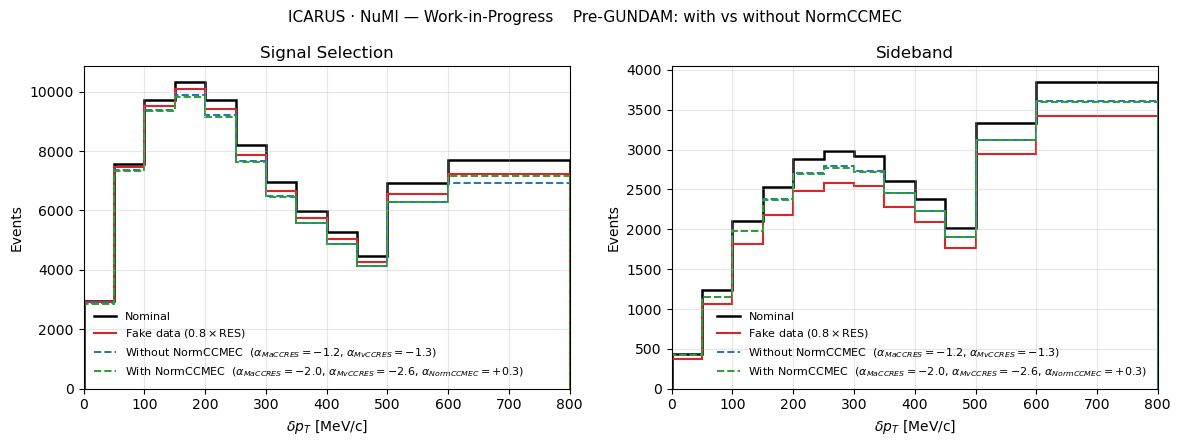

In [8]:
# === Compare: pre-GUNDAM shift fit with vs without NormCCMEC ===

def build_prediction_n(rd, dials_alpha):
    """Multiply per-event weights by every dial's TGraph at its α."""
    total = rd["ppfx_cv_weight"].copy()
    for dial_name, alpha in dials_alpha.items():
        x_axis = rd["dial_x_axes"][dial_name]
        y_mat  = rd["dials"][dial_name]
        total *= tgraph_weight_at_sigma(y_mat, x_axis, alpha)
    return histogram_with_weight(rd["reco_dpT_lp"], total)

def chi2_n(params, dial_names):
    dials_alpha = dict(zip(dial_names, params))
    total = 0.0
    for region in TREES:
        pred = build_prediction_n(data[region], dials_alpha)
        fd   = fakedata[region]
        m    = fd > 0
        total += np.sum((pred[m] - fd[m])**2 / fd[m])
    return total

scenarios = {
    "Without NormCCMEC":  ["MaCCRES", "MvCCRES"],
    "With NormCCMEC":     ["MaCCRES", "MvCCRES", "NormCCMEC"],
}

results = {}
print(f"χ² nominal (all α=0): {chi2_data_only([0.0, 0.0]):.1f}\n")
print(f"{'Scenario':<22} {'α values':<50} {'χ²(fit)':>10}")
print("-" * 90)

for label, dial_list in scenarios.items():
    x0 = [-1.0] * len(dial_list)
    res = minimize(lambda p: chi2_n(p, dial_list), x0=x0,
                   method="Nelder-Mead",
                   options={"xatol": 1e-3, "fatol": 1e-2})
    alphas = dict(zip(dial_list, res.x))
    results[label] = (alphas, res.fun)
    alpha_str = ", ".join(f"α_{n}={v:+.2f}" for n, v in alphas.items())
    print(f"{label:<22} {alpha_str:<50} {res.fun:>10.1f}")

# --- Plot both best-fit predictions over fake data ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, region in zip(axes, TREES):
    ax.stairs(nominal[region],  DPT_BINS, color="k",  lw=1.8, label="Nominal")
    ax.stairs(fakedata[region], DPT_BINS, color="C3", lw=1.5,
              label=r"Fake data ($0.8\times$RES)")
    colors_for_scenarios = ["C0", "C2"]
    for (label, (alphas, _)), c in zip(results.items(), colors_for_scenarios):
        pred = build_prediction_n(data[region], alphas)
        alpha_str = ", ".join(f"$\\alpha_{{{n}}}={v:+.1f}$"
                              for n, v in alphas.items())
        ax.stairs(pred, DPT_BINS, color=c, lw=1.4, ls="--",
                  label=f"{label}  ({alpha_str})")
    ax.set_xlabel(r"$\delta p_T$ [MeV/c]"); ax.set_ylabel("Events")
    ax.set_title(region); ax.legend(frameon=False, fontsize=8)
    ax.set_xlim(DPT_BINS[0], DPT_BINS[-1]); ax.grid(alpha=0.3)
fig.suptitle("ICARUS · NuMI — Work-in-Progress    "
             "Pre-GUNDAM: with vs without NormCCMEC",
             fontsize=11)
fig.tight_layout()
fig.savefig(OUT_DIR / "preGUNDAM_with_vs_without_NormCCMEC.pdf",
            bbox_inches="tight")
save_fig(fig, str(OUT_DIR), 'preGUNDAM_with_vs_without_NormCCMEC')
plt.show()

With dedicated NormCCRES (1σ = 20% rate change on RES):
  α_MaCCRES    = -0.00σ
  α_MvCCRES    = +0.00σ
  α_NormCCRES  = -1.00σ  (-20.0% rate change on RES)
  χ²(fit)      = 0.00

For comparison: previous fits without the dial gave χ²(fit) ≈ 200, templates absorbed the rest.


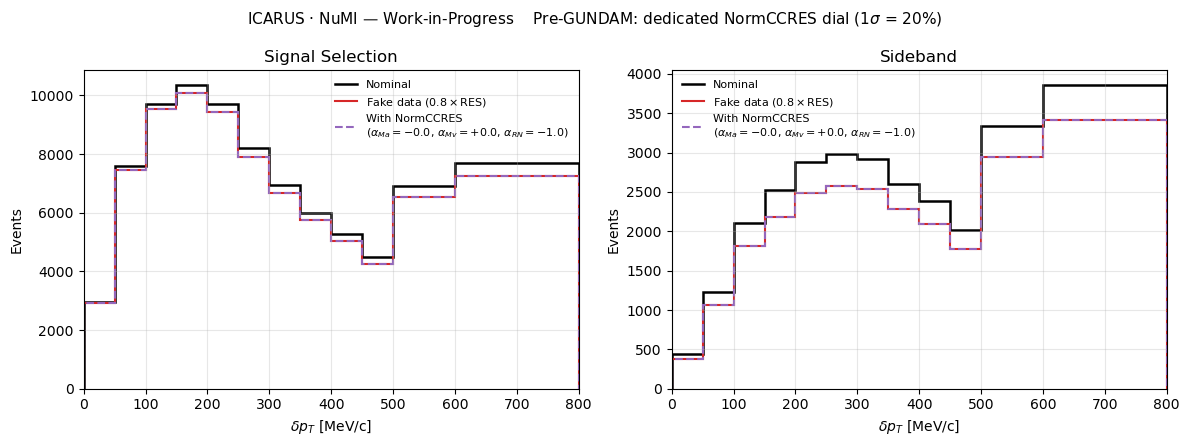

In [9]:
# === Pre-GUNDAM: add a synthetic dedicated NormCCRES dial ===
# Weight prescription: w(α) = 1 + α × σ_RES for events with mode == RES (mode 1),
#                       = 1 otherwise.
# σ_RES sets the prior width per σ shift. 0.20 ≡ 20% rate change at ±1σ.

RES_NORM_WIDTH = 0.20

def build_prediction_with_resnorm(rd, alpha_ma, alpha_mv, alpha_resnorm):
    total = rd["ppfx_cv_weight"].copy()
    x_axis = rd["dial_x_axes"]["MaCCRES"]
    total *= tgraph_weight_at_sigma(rd["dials"]["MaCCRES"], x_axis, alpha_ma)
    total *= tgraph_weight_at_sigma(rd["dials"]["MvCCRES"], x_axis, alpha_mv)
    is_res = (rd["true_interaction_mode"] == RES_MODE)
    total *= np.where(is_res, 1.0 + alpha_resnorm * RES_NORM_WIDTH, 1.0)
    return histogram_with_weight(rd["reco_dpT_lp"], total)

def chi2_resnorm(params):
    a_ma, a_mv, a_rn = params
    total = 0.0
    for region in TREES:
        pred = build_prediction_with_resnorm(data[region], a_ma, a_mv, a_rn)
        fd   = fakedata[region]
        m    = fd > 0
        total += np.sum((pred[m] - fd[m])**2 / fd[m])
    return total

res = minimize(chi2_resnorm, x0=[-0.5, -0.5, -1.0], method="Nelder-Mead",
               options={"xatol": 1e-4, "fatol": 1e-3})
a_ma_b, a_mv_b, a_rn_b = res.x

print(f"With dedicated NormCCRES (1σ = {100*RES_NORM_WIDTH:.0f}% rate change on RES):")
print(f"  α_MaCCRES    = {a_ma_b:+.2f}σ")
print(f"  α_MvCCRES    = {a_mv_b:+.2f}σ")
print(f"  α_NormCCRES  = {a_rn_b:+.2f}σ  "
      f"({100*a_rn_b*RES_NORM_WIDTH:+.1f}% rate change on RES)")
print(f"  χ²(fit)      = {res.fun:.2f}")
print(f"\nFor comparison: previous fits without the dial gave χ²(fit) ≈ 200, "
      f"templates absorbed the rest.")

# --- Plot: nominal, fake data, and best fit with the new dial ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, region in zip(axes, TREES):
    pred_best = build_prediction_with_resnorm(data[region],
                                              a_ma_b, a_mv_b, a_rn_b)
    ax.stairs(nominal[region],  DPT_BINS, color="k",  lw=1.8, label="Nominal")
    ax.stairs(fakedata[region], DPT_BINS, color="C3", lw=1.5,
              label=r"Fake data ($0.8\times$RES)")
    ax.stairs(pred_best, DPT_BINS, color="C4", lw=1.5, ls="--",
              label=(f"With NormCCRES\n"
                     f"($\\alpha_{{Ma}}={a_ma_b:+.1f}$, "
                     f"$\\alpha_{{Mv}}={a_mv_b:+.1f}$, "
                     f"$\\alpha_{{RN}}={a_rn_b:+.1f}$)"))
    ax.set_xlabel(r"$\delta p_T$ [MeV/c]"); ax.set_ylabel("Events")
    ax.set_title(region); ax.legend(frameon=False, fontsize=8)
    ax.set_xlim(DPT_BINS[0], DPT_BINS[-1]); ax.grid(alpha=0.3)
fig.suptitle(f"ICARUS · NuMI — Work-in-Progress    "
             f"Pre-GUNDAM: dedicated NormCCRES dial "
             f"(1$\\sigma$ = {100*RES_NORM_WIDTH:.0f}%)",
             fontsize=11)
fig.tight_layout()
fig.savefig(OUT_DIR / "preGUNDAM_NormCCRES_dedicated.pdf", bbox_inches="tight")
save_fig(fig, str(OUT_DIR), 'preGUNDAM_NormCCRES_dedicated')
plt.show()

Shape-only fake data sanity (rate changes should be near zero):
  Signal Selection: nominal=85806, fake=85470, Δrate=-0.39%
  Sideband: nominal=29301, fake=28960, Δrate=-1.16%

With shape-only RES variation injected:
  α_MaCCRES    = +1.52σ
  α_MvCCRES    = -1.42σ
  α_NormCCRES  = -0.21σ   ← expect ~0 if the new dial doesn't grab work it shouldn't
  χ²(fit)      = 106.47


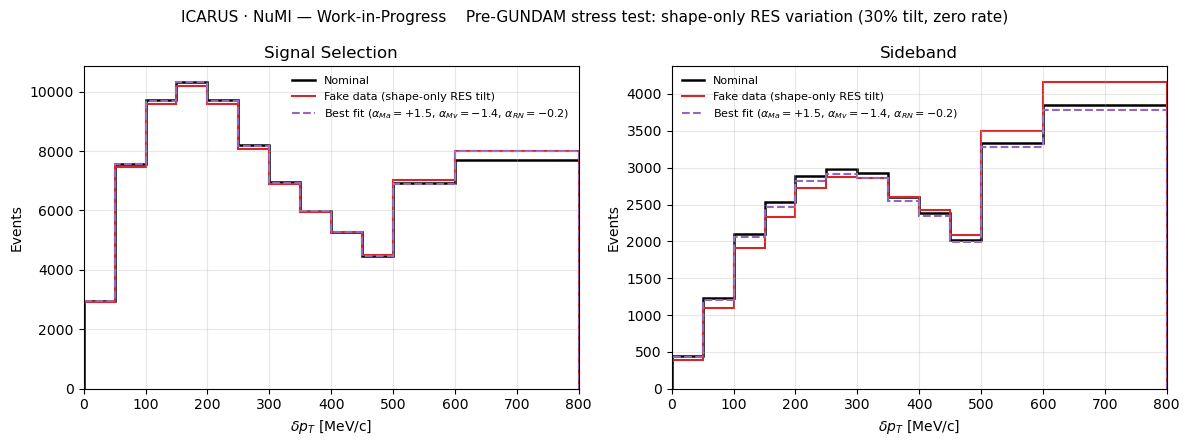

In [10]:
# === Stress test: shape-only RES variation ===
# Apply a linear tilt to RES events in true δpT, renormalized so total RES rate
# is unchanged. The tilt is ±30% at the δpT endpoints (0 and 800 MeV/c).

SHAPE_AMPLITUDE = 0.30
DPT_MID         = 400.0   # MeV/c, pivot of the tilt
DPT_SCALE       = 400.0   # MeV/c, sets the slope

def res_shape_tilt_weights(rd):
    """Per-event weight that tilts RES in truth δpT, area-normalized to zero rate."""
    cv_w   = rd["ppfx_cv_weight"]
    mode   = rd["true_interaction_mode"]
    dpt    = rd["true_dpT_lp"]
    is_res = (mode == RES_MODE)

    finite = np.isfinite(dpt)
    tilt   = np.where(finite,
                      SHAPE_AMPLITUDE * (dpt - DPT_MID) / DPT_SCALE,
                      0.0)
    w_shape = 1.0 + tilt
    # Renormalize so the integrated weight over RES events is 1
    nom_rate = np.sum(cv_w[is_res])
    new_rate = np.sum(cv_w[is_res] * w_shape[is_res])
    w_shape_normed = w_shape * (nom_rate / new_rate)

    return np.where(is_res, w_shape_normed, 1.0)

def build_fakedata_shape(rd):
    cv_w    = rd["ppfx_cv_weight"]
    shape_w = res_shape_tilt_weights(rd)
    return histogram_with_weight(rd["reco_dpT_lp"], cv_w * shape_w)

fakedata_shape = {region: build_fakedata_shape(data[region]) for region in TREES}

print("Shape-only fake data sanity (rate changes should be near zero):")
for region in TREES:
    nom = nominal[region].sum()
    fds = fakedata_shape[region].sum()
    print(f"  {region}: nominal={nom:.0f}, fake={fds:.0f}, "
          f"Δrate={100*(fds-nom)/nom:+.2f}%")

# Fit with (MaCCRES, MvCCRES, NormCCRES) free
def chi2_shape_only(params):
    a_ma, a_mv, a_rn = params
    total = 0.0
    for region in TREES:
        pred = build_prediction_with_resnorm(data[region], a_ma, a_mv, a_rn)
        fd   = fakedata_shape[region]
        m    = fd > 0
        total += np.sum((pred[m] - fd[m])**2 / fd[m])
    return total

res = minimize(chi2_shape_only, x0=[0.0, 0.0, 0.0],
               method="Nelder-Mead",
               options={"xatol": 1e-4, "fatol": 1e-3})
a_ma_b, a_mv_b, a_rn_b = res.x

print(f"\nWith shape-only RES variation injected:")
print(f"  α_MaCCRES    = {a_ma_b:+.2f}σ")
print(f"  α_MvCCRES    = {a_mv_b:+.2f}σ")
print(f"  α_NormCCRES  = {a_rn_b:+.2f}σ"
      f"   ← expect ~0 if the new dial doesn't grab work it shouldn't")
print(f"  χ²(fit)      = {res.fun:.2f}")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, region in zip(axes, TREES):
    pred_best = build_prediction_with_resnorm(data[region], a_ma_b, a_mv_b, a_rn_b)
    ax.stairs(nominal[region],        DPT_BINS, color="k",  lw=1.8, label="Nominal")
    ax.stairs(fakedata_shape[region], DPT_BINS, color="C3", lw=1.5,
              label="Fake data (shape-only RES tilt)")
    ax.stairs(pred_best, DPT_BINS, color="C4", lw=1.5, ls="--",
              label=(f"Best fit ($\\alpha_{{Ma}}={a_ma_b:+.1f}$, "
                     f"$\\alpha_{{Mv}}={a_mv_b:+.1f}$, "
                     f"$\\alpha_{{RN}}={a_rn_b:+.1f}$)"))
    ax.set_xlabel(r"$\delta p_T$ [MeV/c]"); ax.set_ylabel("Events")
    ax.set_title(region); ax.legend(frameon=False, fontsize=8)
    ax.set_xlim(DPT_BINS[0], DPT_BINS[-1]); ax.grid(alpha=0.3)
fig.suptitle(f"ICARUS · NuMI — Work-in-Progress    "
             f"Pre-GUNDAM stress test: shape-only RES variation "
             f"({int(100*SHAPE_AMPLITUDE)}% tilt, zero rate)",
             fontsize=11)
fig.tight_layout()
fig.savefig(OUT_DIR / "preGUNDAM_RES_shape_only.pdf", bbox_inches="tight")
save_fig(fig, str(OUT_DIR), 'preGUNDAM_RES_shape_only')
plt.show()

In [1]:
import uproot
import numpy as np

NEW_FILE = (
    "/Users/rvizarreta/Library/CloudStorage/"
    "GoogleDrive-rvizarreta14@gmail.com/My Drive/"
    "🏛 PhD Repository/🚀 Research/🤖 Experiments&Projects/"
    "ICARUS/ICARUS_CC0pi_Selection/data/"
    "icarus_numi_numu_mc_onbeam_offbeam_syst_gundam_withPCA_NormCCRES.root"
)

f = uproot.open(NEW_FILE)
t = f["events/full/selected"]

# 1. Does the branch exist, and as what?
print("=== Branches matching NormCCRES ===")
for k in t.keys():
    if "NormCCRES" in k:
        print(f"  {k}")

# 2. Try to read it the same way the existing branches were read
print("\n=== Reading attempt ===")
try:
    br = t["Synthetic_multisigma_NormCCRES"].array(
        library="np", entry_stop=5
    )
    print(f"Outer type: {type(br).__name__}, dtype={br.dtype}, len={len(br)}")
    print(f"First entry type: {type(br[0]).__name__}")
    print(f"First entry: {br[0]}")

    # 3. Try to dig into the TClonesArray → TGraph
    tg = next(iter(br[0]))
    print(f"\nFirst graph type: {type(tg).__name__}")
    print(f"fX: {np.asarray(tg.member('fX'))}")
    print(f"fY: {np.asarray(tg.member('fY'))}")
except Exception as e:
    print(f"Read failed: {type(e).__name__}: {e}")

# 4. Read the mode branch and check we can correlate
print("\n=== Cross-check vs mode ===")
mode = t["true_interaction_mode"].array(library="np", entry_stop=5)
print(f"First 5 modes: {mode}")

=== Branches matching NormCCRES ===
  Synthetic_multisigma_NormCCRES

=== Reading attempt ===
Outer type: ndarray, dtype=object, len=5
First entry type: Model_TClonesArray
First entry: <TClonesArray at 0x000105b22e40>

First graph type: Model_TGraph_v5
fX: [-3. -2. -1.  0.  1.  2.  3.]
fY: [0.4 0.6 0.8 1.  1.2 1.4 1.6]

=== Cross-check vs mode ===
First 5 modes: [ 1.  0. 10.  1. 10.]


In [2]:
# Find a non-RES event (mode != 1) and check its TGraph is flat at 1.0
br = t["Synthetic_multisigma_NormCCRES"].array(library="np", entry_stop=20)
modes = t["true_interaction_mode"].array(library="np", entry_stop=20)
for i, m in enumerate(modes):
    if m != 1:
        tg = next(iter(br[i]))
        print(f"Event {i}: mode={int(m)}, fY = {np.asarray(tg.member('fY'))}")
        break

Event 1: mode=0, fY = [1. 1. 1. 1. 1. 1. 1.]


In [21]:
# === Python (MaCCRES, MvCCRES) prior-width scan against RES ×0.8 fake data ===
import uproot
import numpy as np
import pandas as pd
from scipy.optimize import minimize

DIALS = ["MaCCRES", "MvCCRES"]
PRIOR_WIDTHS = [1.0, 2.0, 3.0, 5.0, np.inf]  # ×1, ×2, ×3, ×5, unconstrained
FAKE_DATA_INJECTION = 0.8                     # RES ×0.8

# Adjust to your actual analysis binning in GeV/c
BIN_EDGES = np.array([0.0, 0.08, 0.16, 0.24, 0.32, 0.40, 0.55, 0.80])


def load_tree(tree):
    n = tree.num_entries
    out = {
        "modes":    tree["true_interaction_mode"].array(library="np"),
        "ppfx":     tree["ppfx_cv_weight"].array(library="np"),
        "reco_dpT": tree["reco_dpT_lp"].array(library="np") / 1000.0,
    }
    fX = None
    for dial in DIALS:
        branch = f"GENIEReWeight_SBN_v1_multisigma_{dial}"
        tgs = tree[branch].array(library="np", entry_stop=n)
        fY_dial = np.ones((n, 7))
        for i, tca in enumerate(tgs):
            if tca is None or len(tca) == 0:
                continue
            tg = next(iter(tca))
            if fX is None:
                fX = np.asarray(tg.member("fX"))
            fY_dial[i] = np.asarray(tg.member("fY"))
        out[dial] = fY_dial
    out["fX"] = fX
    return out


print("Loading signal selection (slowest step; a couple of minutes)...")
sig  = load_tree(uproot.open(FILE)["events/full/selected"])
print("Loading sideband...")
side = load_tree(uproot.open(FILE)["events/full/sideband"])


def lin_interp(fY_all, fX, alpha):
    """Linear interp in alpha across the 7-point grid."""
    if alpha <= fX[0]:  return fY_all[:, 0]
    if alpha >= fX[-1]: return fY_all[:, -1]
    k = int(np.searchsorted(fX, alpha)) - 1
    frac = (alpha - fX[k]) / (fX[k+1] - fX[k])
    return fY_all[:, k] + frac * (fY_all[:, k+1] - fY_all[:, k])


def predict(data, a_ma, a_mv):
    w  = data["ppfx"].copy()
    w *= lin_interp(data["MaCCRES"], data["fX"], a_ma)
    w *= lin_interp(data["MvCCRES"], data["fX"], a_mv)
    return np.histogram(data["reco_dpT"], bins=BIN_EDGES, weights=w)[0]


# Nominal histograms
nom_sig  = predict(sig,  0.0, 0.0)
nom_side = predict(side, 0.0, 0.0)

# Fake data: RES events ×0.8
fake_w_sig  = sig ["ppfx"] * np.where(sig ["modes"] == 1, FAKE_DATA_INJECTION, 1.0)
fake_w_side = side["ppfx"] * np.where(side["modes"] == 1, FAKE_DATA_INJECTION, 1.0)
fake_sig  = np.histogram(sig ["reco_dpT"], bins=BIN_EDGES, weights=fake_w_sig )[0]
fake_side = np.histogram(side["reco_dpT"], bins=BIN_EDGES, weights=fake_w_side)[0]


def chi2(params, prior_width):
    a_ma, a_mv = params
    pred_sig  = predict(sig,  a_ma, a_mv)
    pred_side = predict(side, a_ma, a_mv)
    var_sig   = np.maximum(fake_sig,  1.0)
    var_side  = np.maximum(fake_side, 1.0)
    chi2_data = (((pred_sig  - fake_sig )**2 / var_sig ).sum() +
                 ((pred_side - fake_side)**2 / var_side).sum())
    chi2_prior = 0.0 if not np.isfinite(prior_width) \
                 else (a_ma**2 + a_mv**2) / prior_width**2
    return chi2_data + chi2_prior


# Scan
print("\nScanning prior widths:\n")
rows = []
for sigma in PRIOR_WIDTHS:
    label = "unconstrained" if not np.isfinite(sigma) else f"×{int(sigma)}"
    res = minimize(chi2, x0=[0.0, 0.0], args=(sigma,),
                   method="Nelder-Mead",
                   options={"xatol": 1e-3, "fatol": 1e-2, "maxiter": 400})
    a_ma, a_mv = res.x
    chi2_total = res.fun
    chi2_data  = chi2_total if not np.isfinite(sigma) \
                 else chi2_total - (a_ma**2 + a_mv**2) / sigma**2
    rows.append({
        "prior":         label,
        "α_MaCCRES":     a_ma,
        "α_MvCCRES":     a_mv,
        "χ²_data":       chi2_data,
        "χ²_total":      chi2_total,
    })
    print(f"  {label:>15s}:   α_Ma = {a_ma:+.3f},   α_Mv = {a_mv:+.3f},   "
          f"χ²_data = {chi2_data:7.2f}")

df = pd.DataFrame(rows)
print("\nSummary:")
print(df.to_string(index=False, float_format=lambda x: f"{x:.3f}"))

Loading signal selection (slowest step; a couple of minutes)...
Loading sideband...

Scanning prior widths:

               ×1:   α_Ma = -2.000,   α_Mv = +0.259,   χ²_data =  214.00
               ×2:   α_Ma = -2.310,   α_Mv = +0.681,   χ²_data =  213.38
               ×3:   α_Ma = -2.834,   α_Mv = +1.327,   χ²_data =  209.88
               ×5:   α_Ma = -2.843,   α_Mv = +1.335,   χ²_data =  209.88
    unconstrained:   α_Ma = -2.848,   α_Mv = +1.339,   χ²_data =  209.88

Summary:
        prior  α_MaCCRES  α_MvCCRES  χ²_data  χ²_total
           ×1     -2.000      0.259  214.002   218.069
           ×2     -2.310      0.681  213.378   214.829
           ×3     -2.834      1.327  209.881   210.969
           ×5     -2.843      1.335  209.876   210.271
unconstrained     -2.848      1.339  209.875   209.875
